# Classification of Ice and Open Water of Yukon River using Sentinel-1 IW Product

This notebook classifies ice and open water in the Yukon River using Sentinel-1 SAR imagery from September to May across three winter seasons: **2022/23, 2023/24, and 2024/25**. The methodology was adapted from the Copernicus Data Space Ecosystem Documentation: https://documentation.dataspace.copernicus.eu/notebook-samples/sentinelhub/ice_monitoring.html

The **Tanana River Confluence** connects the Yukon River to the Tanana River, which is a major shipping artery in interior Alaska. Nenana, located on the Tanana River, is a central hub for Ruby Marine that transports heavy goods, oil, and vehicles to inland communities. Monitoring ice extent and freeze-thaw timing at this confluence is directly relevant to navigation safety and community logistics planning.

## Imports

In [21]:
import datetime
import json
import os

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
import numpy as np
import geopandas as gpd
from ipyleaflet import Map, GeoJSON, basemaps

from sentinelhub import (
    SHConfig,
    Geometry,
    DataCollection,
    MimeType,
    SentinelHubCatalog,
    SentinelHubDownloadClient,
    SentinelHubRequest,
    BBox,
    CRS,
)

## Credentials

Sentinel Hub credentials are read from environment variables rather than stored in the notebook.

Before running the notebook, set:

- `SH_CLIENT_ID`
- `SH_CLIENT_SECRET`

This keeps credentials out of Git history and shared notebooks. If credentials were previously committed to a public repository, rotate the client secret before continuing.

In [22]:
# Configure Sentinel Hub credentials for the Copernicus Data Space Ecosystem (CDSE)
config = SHConfig()

config.sh_client_id = "sh-e97606ba-80ad-422b-82f7-a57245149057"
config.sh_client_secret = "nQg5VU4hIL4hOcB9pQRQyCNTtUThWScN"
config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
config.sh_base_url = "https://sh.dataspace.copernicus.eu"

if not config.sh_client_id or not config.sh_client_secret:
    raise RuntimeError(
        "Missing Sentinel Hub credentials. Set SH_CLIENT_ID and SH_CLIENT_SECRET "
        "as environment variables before running this notebook."
    )

## Configuration

All user-configurable parameters are defined here in one place for clarity and ease of modification.

In [23]:
# ── Study area ────────────────────────────────────────────────────────────────
SHAPE_PATH = "../data/raw/confluence_aoi.geojson"
METRIC_CRS = "EPSG:32606"   # UTM Zone 6N — appropriate for the Tanana–Yukon confluence

# ── Seasons to analyse ────────────────────────────────────────────────────────
# Each season runs September–May across the freeze-thaw period.
START_YEARS = [2022, 2023, 2024]  # e.g. 2022 → 2022-09-01 to 2023-05-31

# ── Time slicing ──────────────────────────────────────────────────────────────
N_CHUNKS = 19             # Number of equal time slots per season (~two weeks each)
SEASON_START_MONTH = 9    # September
SEASON_END_MONTH = 5      # May
SEASON_END_DAY = 31

# ── SAR request parameters ────────────────────────────────────────────────────
RESOLUTION = 40           # Spatial resolution in metres

# Threshold is expressed directly in calibrated VV backscatter (dB).
# -14 dB is used as a simple heuristic threshold based on visual comparison
# of known open-water and winter backscatter distributions within the river-only AOI.
# It is not an algorithmically optimized threshold.
ICE_THRESHOLD_DB = -14.0

# ── Map display ───────────────────────────────────────────────────────────────
MAP_CENTER = [65.15, -151.90]
MAP_ZOOM = 9

# ── Output paths ──────────────────────────────────────────────────────────────
# New folders avoid mixing revised dB products with TIFFs created by the older
# normalized-backscatter workflow.
SAR_DATA_FOLDER = "../data/results/sar_db"
MASK_DATA_FOLDER = "../data/results/mask_db_m14"

## Defining the Area of Interest

Load the GeoJSON for the Tanana–Yukon confluence and display it on an interactive map. The geometry is reprojected to UTM Zone 6N (EPSG:32606) for metric resolution calculations, while the WGS84 version is retained for visualisation.

In [24]:
# Load AOI and reproject to metric CRS for resolution/area calculations
river_gdf = gpd.read_file(SHAPE_PATH)                    # original WGS84
river_gdf_metric = river_gdf.to_crs(METRIC_CRS)         # projected (metres)

print(f"CRS (metric): {river_gdf_metric.crs}")
print(f"Bounds (metres): {river_gdf_metric.total_bounds}")

# Load raw GeoJSON for ipyleaflet visualisation
with open(SHAPE_PATH, "r") as f:
    data_geojson = json.load(f)

# Display AOI on an interactive map
m = Map(basemap=basemaps.CartoDB.Voyager, center=MAP_CENTER, zoom=MAP_ZOOM)
m.add_layer(GeoJSON(data=data_geojson))
m

CRS (metric): EPSG:32606
Bounds (metres): [ 253843.19914737 7232950.54977846  273941.5935925  7239963.3757012 ]


Map(center=[65.15, -151.9], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_…

## Check Sentinel-1 Data Availability

Query the Sentinel Hub Catalog to verify how many Sentinel-1 IW scenes are available over the AOI for each season before committing to a full download.

In [25]:
# Build per-season date ranges and catalogue bbox
date_ranges = {
    year: (f"{year}-{SEASON_START_MONTH:02d}-01",
           f"{year + 1}-{SEASON_END_MONTH:02d}-{SEASON_END_DAY}")
    for year in START_YEARS
}

catalog = SentinelHubCatalog(config=config)
catalog_bbox = BBox(tuple(river_gdf.total_bounds), crs=CRS.WGS84)
s1_collection = DataCollection.SENTINEL1_IW.define_from("s1iw", service_url=config.sh_base_url)

all_catalog_results = {}
for year, (t_start, t_end) in date_ranges.items():
    scenes = list(catalog.search(
        s1_collection,
        bbox=catalog_bbox,
        time=(t_start, t_end),
        fields={"include": ["id", "properties.datetime"], "exclude": []},
    ))
    all_catalog_results[year] = scenes
    print(f"Season {year}/{year + 1}: {len(scenes)} scenes found ({t_start} → {t_end})")

print(f"\nTotal scenes across all seasons: {sum(len(v) for v in all_catalog_results.values())}")

Season 2022/2023: 40 scenes found (2022-09-01 → 2023-05-31)
Season 2023/2024: 43 scenes found (2023-09-01 → 2024-05-31)
Season 2024/2025: 56 scenes found (2024-09-01 → 2025-05-31)

Total scenes across all seasons: 139


## Define Time Slots

Each September–May season is divided into **19 equal time slots** (roughly two weeks each) to capture freeze-thaw dynamics. The revised function creates **20 interval edges for 19 intervals**, ensuring that the final slot reaches May 31.

In [26]:
def build_time_slots(start_year: int, n_chunks: int = N_CHUNKS) -> list[tuple[str, str]]:
    """Generate exactly n_chunks (start, end) ISO-date intervals for one season."""
    start = datetime.datetime(start_year, SEASON_START_MONTH, 1)
    end = datetime.datetime(start_year + 1, SEASON_END_MONTH, SEASON_END_DAY)

    delta = (end - start) / n_chunks
    edges = [(start + i * delta).date().isoformat() for i in range(n_chunks + 1)]

    # Guard against any date-rounding drift at the endpoints.
    edges[0] = start.date().isoformat()
    edges[-1] = end.date().isoformat()

    return [(edges[i], edges[i + 1]) for i in range(n_chunks)]


season_slots: dict[int, list[tuple[str, str]]] = {
    year: build_time_slots(year) for year in START_YEARS
}

for year, slots in season_slots.items():
    print(f"\nSeason {year}/{year + 1} — {len(slots)} slots:")
    for slot in slots:
        print(f"  {slot[0]}  →  {slot[1]}")


Season 2022/2023 — 19 slots:
  2022-09-01  →  2022-09-15
  2022-09-15  →  2022-09-29
  2022-09-29  →  2022-10-13
  2022-10-13  →  2022-10-28
  2022-10-28  →  2022-11-11
  2022-11-11  →  2022-11-25
  2022-11-25  →  2022-12-10
  2022-12-10  →  2022-12-24
  2022-12-24  →  2023-01-07
  2023-01-07  →  2023-01-22
  2023-01-22  →  2023-02-05
  2023-02-05  →  2023-02-19
  2023-02-19  →  2023-03-06
  2023-03-06  →  2023-03-20
  2023-03-20  →  2023-04-03
  2023-04-03  →  2023-04-18
  2023-04-18  →  2023-05-02
  2023-05-02  →  2023-05-16
  2023-05-16  →  2023-05-31

Season 2023/2024 — 19 slots:
  2023-09-01  →  2023-09-15
  2023-09-15  →  2023-09-29
  2023-09-29  →  2023-10-14
  2023-10-14  →  2023-10-28
  2023-10-28  →  2023-11-11
  2023-11-11  →  2023-11-26
  2023-11-26  →  2023-12-10
  2023-12-10  →  2023-12-24
  2023-12-24  →  2024-01-08
  2024-01-08  →  2024-01-22
  2024-01-22  →  2024-02-06
  2024-02-06  →  2024-02-20
  2024-02-20  →  2024-03-05
  2024-03-05  →  2024-03-20
  2024-03-20  → 

## Evalscripts and Request Builders

### SAR Evalscript

The revised SAR evalscript:

- inputs Sentinel-1 VV and `dataMask`
- converts calibrated linear VV backscatter directly to **decibels (dB)**
- preserves the dB values as `FLOAT32`
- avoids the previous custom 0–1 normalization

Sentinel Hub preprocessing remains:

- **Radiometric calibration:** `SIGMA0_ELLIPSOID`
- **Speckle filter:** Lee 3×3
- **Geometric correction:** COPERNICUS DEM
- **Resolution:** 40 m × 40 m

### Ice Mask Evalscript

The classification threshold is now expressed in physically interpretable dB units:

- **Blue** → open water candidate (`VV < ICE_THRESHOLD_DB`)
- **Cyan** → probable ice (`VV ≥ ICE_THRESHOLD_DB`)
- **Black** → no data

The AOI GeoJSON contains only river water, so the workflow does not need to compensate for surrounding boreal terrain. The threshold should instead be evaluated from the observed open-water and winter backscatter distributions within the river AOI itself.

In [27]:
# ── Evalscript: calibrated VV backscatter in dB (FLOAT32) ─────────────────────
EVALSCRIPT_SAR = """
function setup() {
  return {
    input: ["VV", "dataMask"],
    output: { bands: 2, sampleType: "FLOAT32" }
  };
}

function toDb(linear) {
  return 10 * Math.log(Math.max(linear, 1e-10)) / Math.LN10;
}

function evaluatePixel(sample) {
  if (sample.dataMask === 0) {
    return [NaN, 0];
  }
  return [toDb(sample.VV), sample.dataMask];
}
"""

# ── Evalscript: ice / water classification mask (UINT8) ───────────────────────
EVALSCRIPT_MASK = f"""
function setup() {{
  return {{
    input: ["VV", "dataMask"],
    output: {{ bands: 5, sampleType: "UINT8" }}
  }};
}}

function toDb(linear) {{
  return 10 * Math.log(Math.max(linear, 1e-10)) / Math.LN10;
}}

function evaluatePixel(sample) {{
  if (sample.dataMask === 0) {{
    return [0, 0, 0, 0, 0];
  }}

  var vvDb = toDb(sample.VV);

  if (vvDb >= {ICE_THRESHOLD_DB}) {{
    return [0, 255, 255, 1, 1];
  }} else {{
    return [0, 0, 255, 1, 0];
  }}
}}
"""

def build_s1_input_data(time_interval: tuple[str, str]):
    """Build Sentinel-1 input data for one time interval."""
    return [
        SentinelHubRequest.input_data(
            data_collection=DataCollection.SENTINEL1_IW.define_from(
                "s1iw", service_url=config.sh_base_url
            ),
            time_interval=time_interval,
            other_args={
                "dataFilter": {
                    "resolution": "HIGH",
                    "mosaickingOrder": "mostRecent",
                },
                "processing": {
                    "backCoeff": "SIGMA0_ELLIPSOID",
                    "orthorectify": True,
                    "demInstance": "COPERNICUS",
                    "speckleFilter": {
                        "type": "LEE",
                        "windowSizeX": 3,
                        "windowSizeY": 3,
                    },
                },
            },
        )
    ]

def get_sar_request(time_interval: tuple[str, str]) -> SentinelHubRequest:
    """Build a Process API request for calibrated VV backscatter in dB."""
    return SentinelHubRequest(
        evalscript=EVALSCRIPT_SAR,
        input_data=build_s1_input_data(time_interval),
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        geometry=Geometry(
            river_gdf_metric.geometry.values[0],
            crs=river_gdf_metric.crs,
        ),
        resolution=[RESOLUTION, RESOLUTION],
        config=config,
        data_folder=SAR_DATA_FOLDER,
    )

def get_ice_mask_request(time_interval: tuple[str, str]) -> SentinelHubRequest:
    """Build a Process API request for the classified ice/water mask."""
    return SentinelHubRequest(
        evalscript=EVALSCRIPT_MASK,
        input_data=build_s1_input_data(time_interval),
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        geometry=Geometry(
            river_gdf_metric.geometry.values[0],
            crs=river_gdf_metric.crs,
        ),
        resolution=[RESOLUTION, RESOLUTION],
        config=config,
        data_folder=MASK_DATA_FOLDER,
    )

def download_season(slots: list[tuple[str, str]], request_fn) -> list:
    """Download Sentinel Hub data for all time slots in one season."""
    requests = [request_fn(slot) for slot in slots]
    download_list = [req.download_list[0] for req in requests]
    return SentinelHubDownloadClient(config=config).download(
        download_list, max_threads=1
    )

## Download SAR Data

Download calibrated VV backscatter in **dB** for all three seasons. The revised workflow uses a new cache directory (`sar_db`) so previously downloaded normalized TIFFs are not reused accidentally.

In [28]:
season_sar_data: dict[int, list] = {}

for year, slots in season_slots.items():
    print(f"Downloading SAR data for season {year}/{year + 1} ({len(slots)} slots)...")
    season_sar_data[year] = download_season(slots, get_sar_request)

    valid = sum(
        1
        for img in season_sar_data[year]
        if img.ndim == 3 and np.any(img[:, :, 1] > 0)
    )
    print(f"  ✓ Done — {valid}/{len(slots)} slots contain valid data\n")

  ✓ Done — 17/19 slots contain valid data

  ✓ Done — 19/19 slots contain valid data

  ✓ Done — 19/19 slots contain valid data



## Visualise SAR Imagery (VV Backscatter in dB)

Each panel shows calibrated VV backscatter. Brighter pixels represent stronger radar returns. Display scaling is based on the 2nd–98th percentiles of the valid observations for each season so the visualization is not tied to the old normalized 0–1 range.

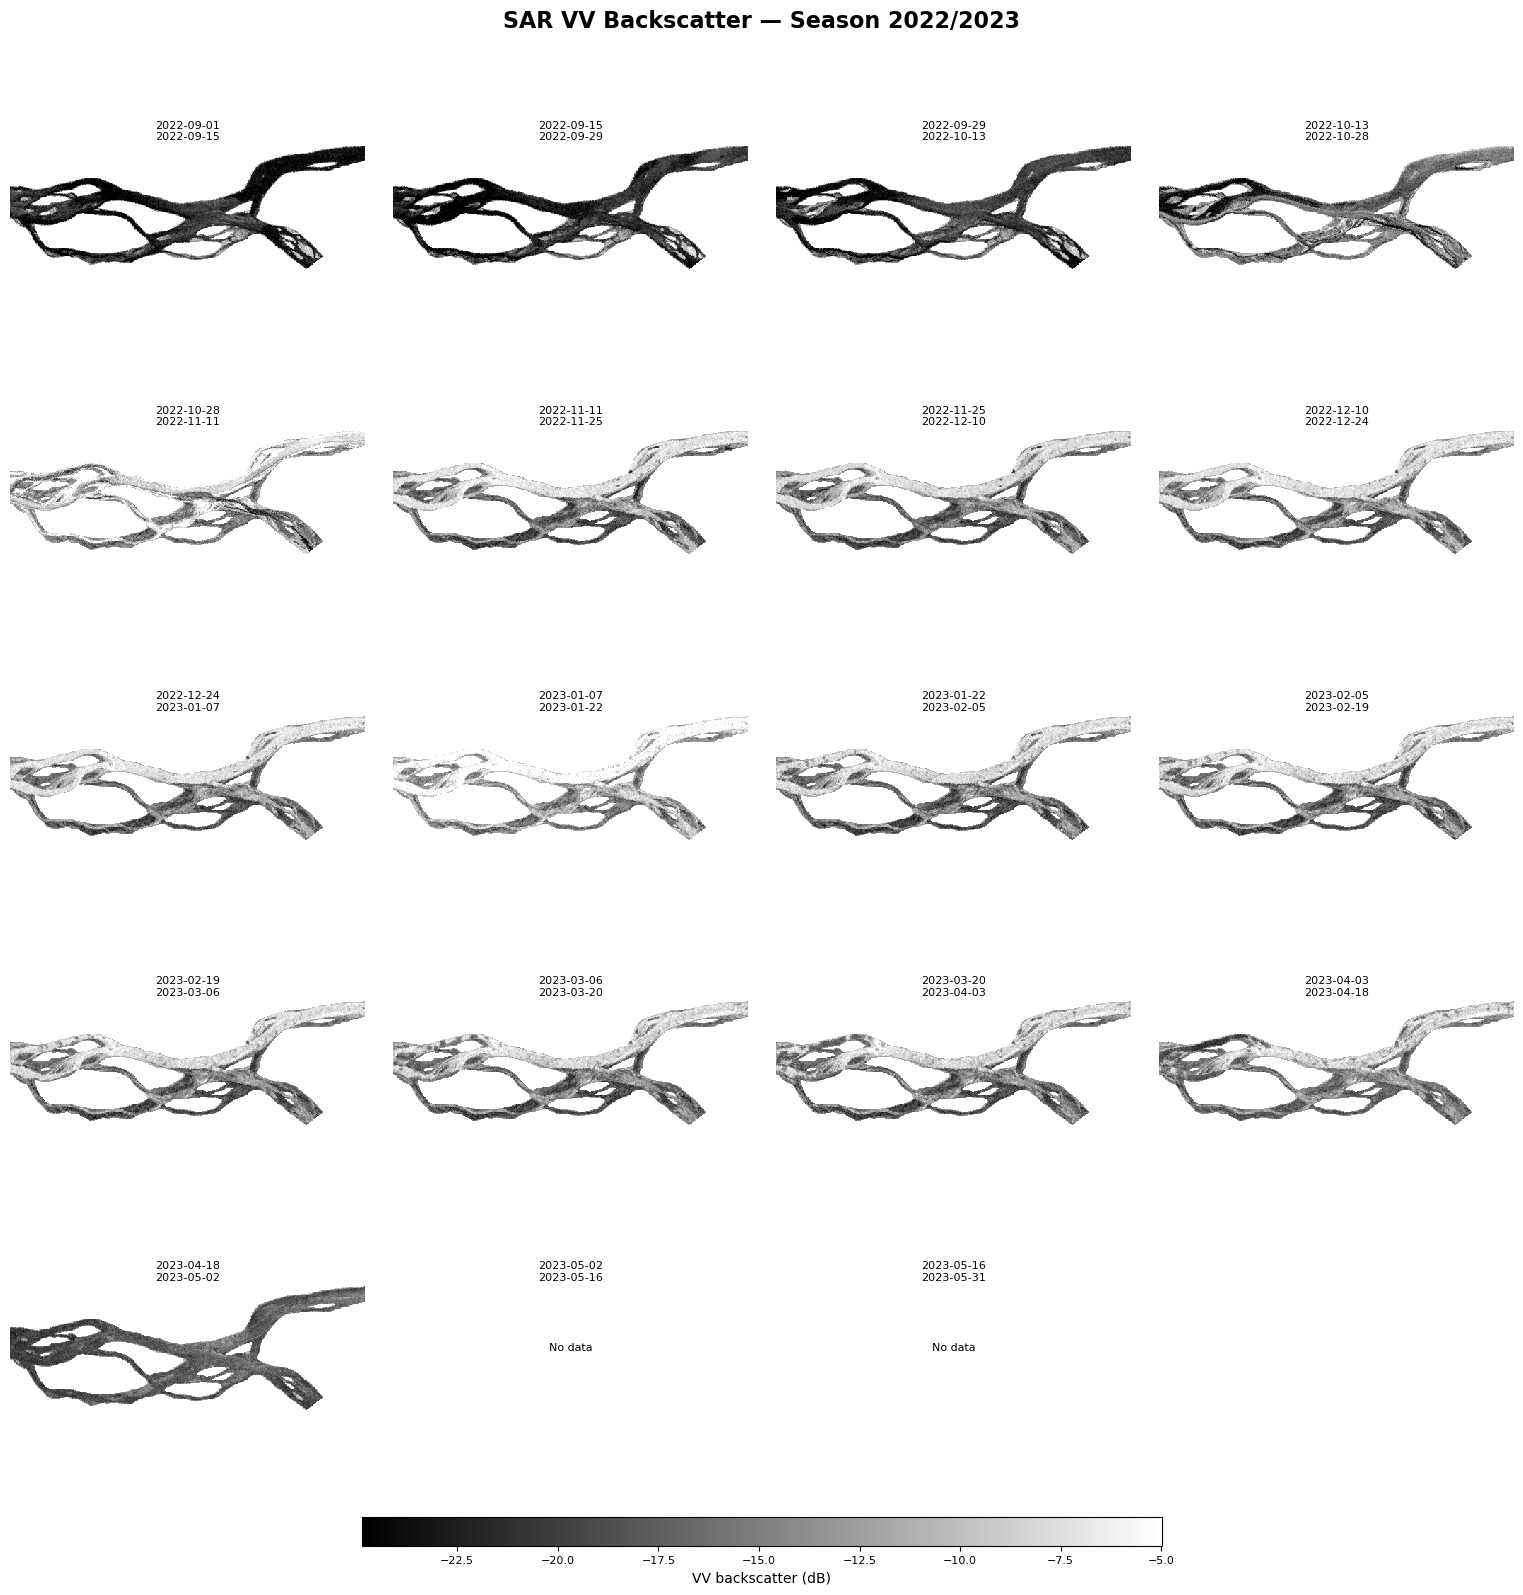

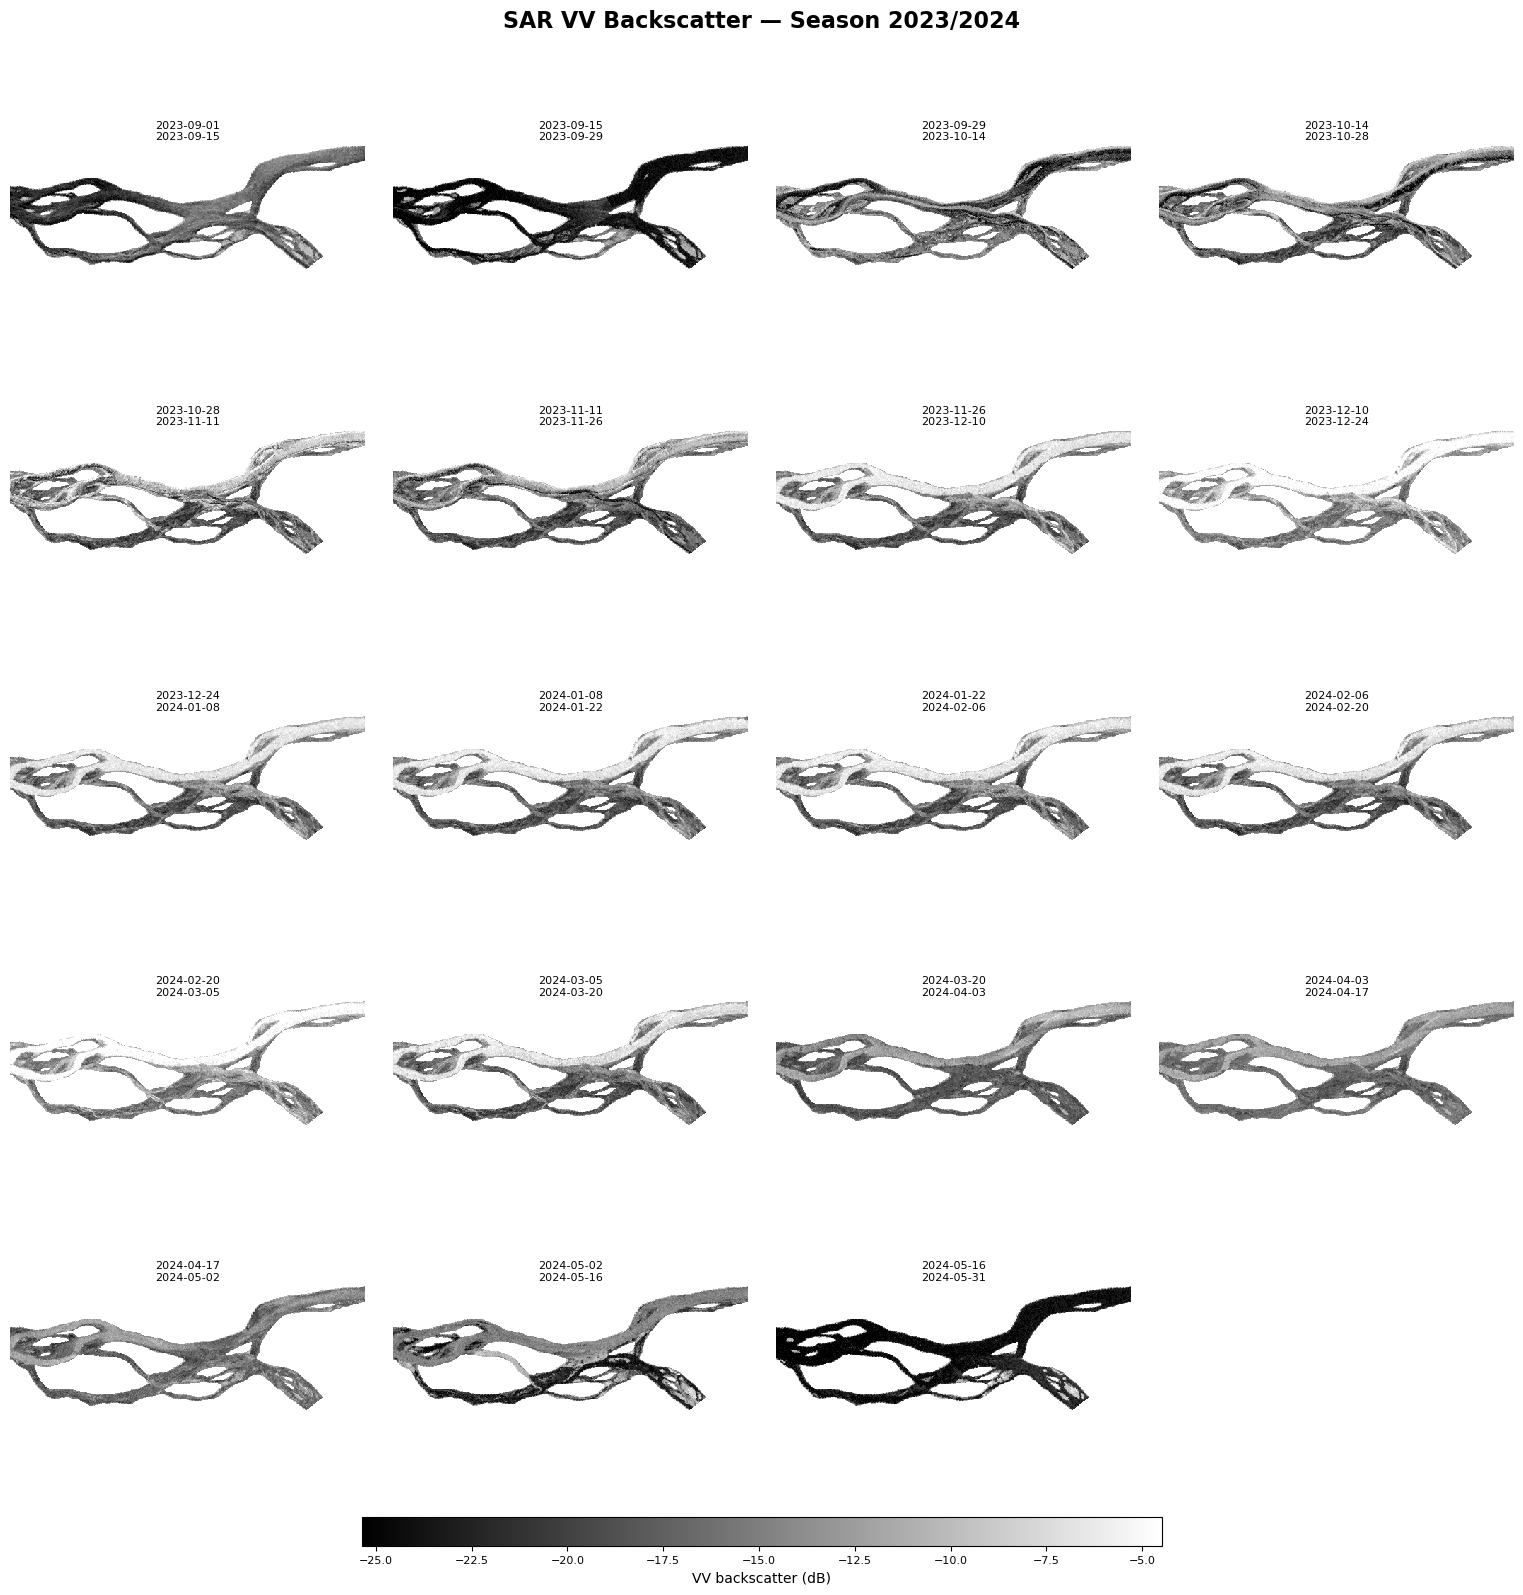

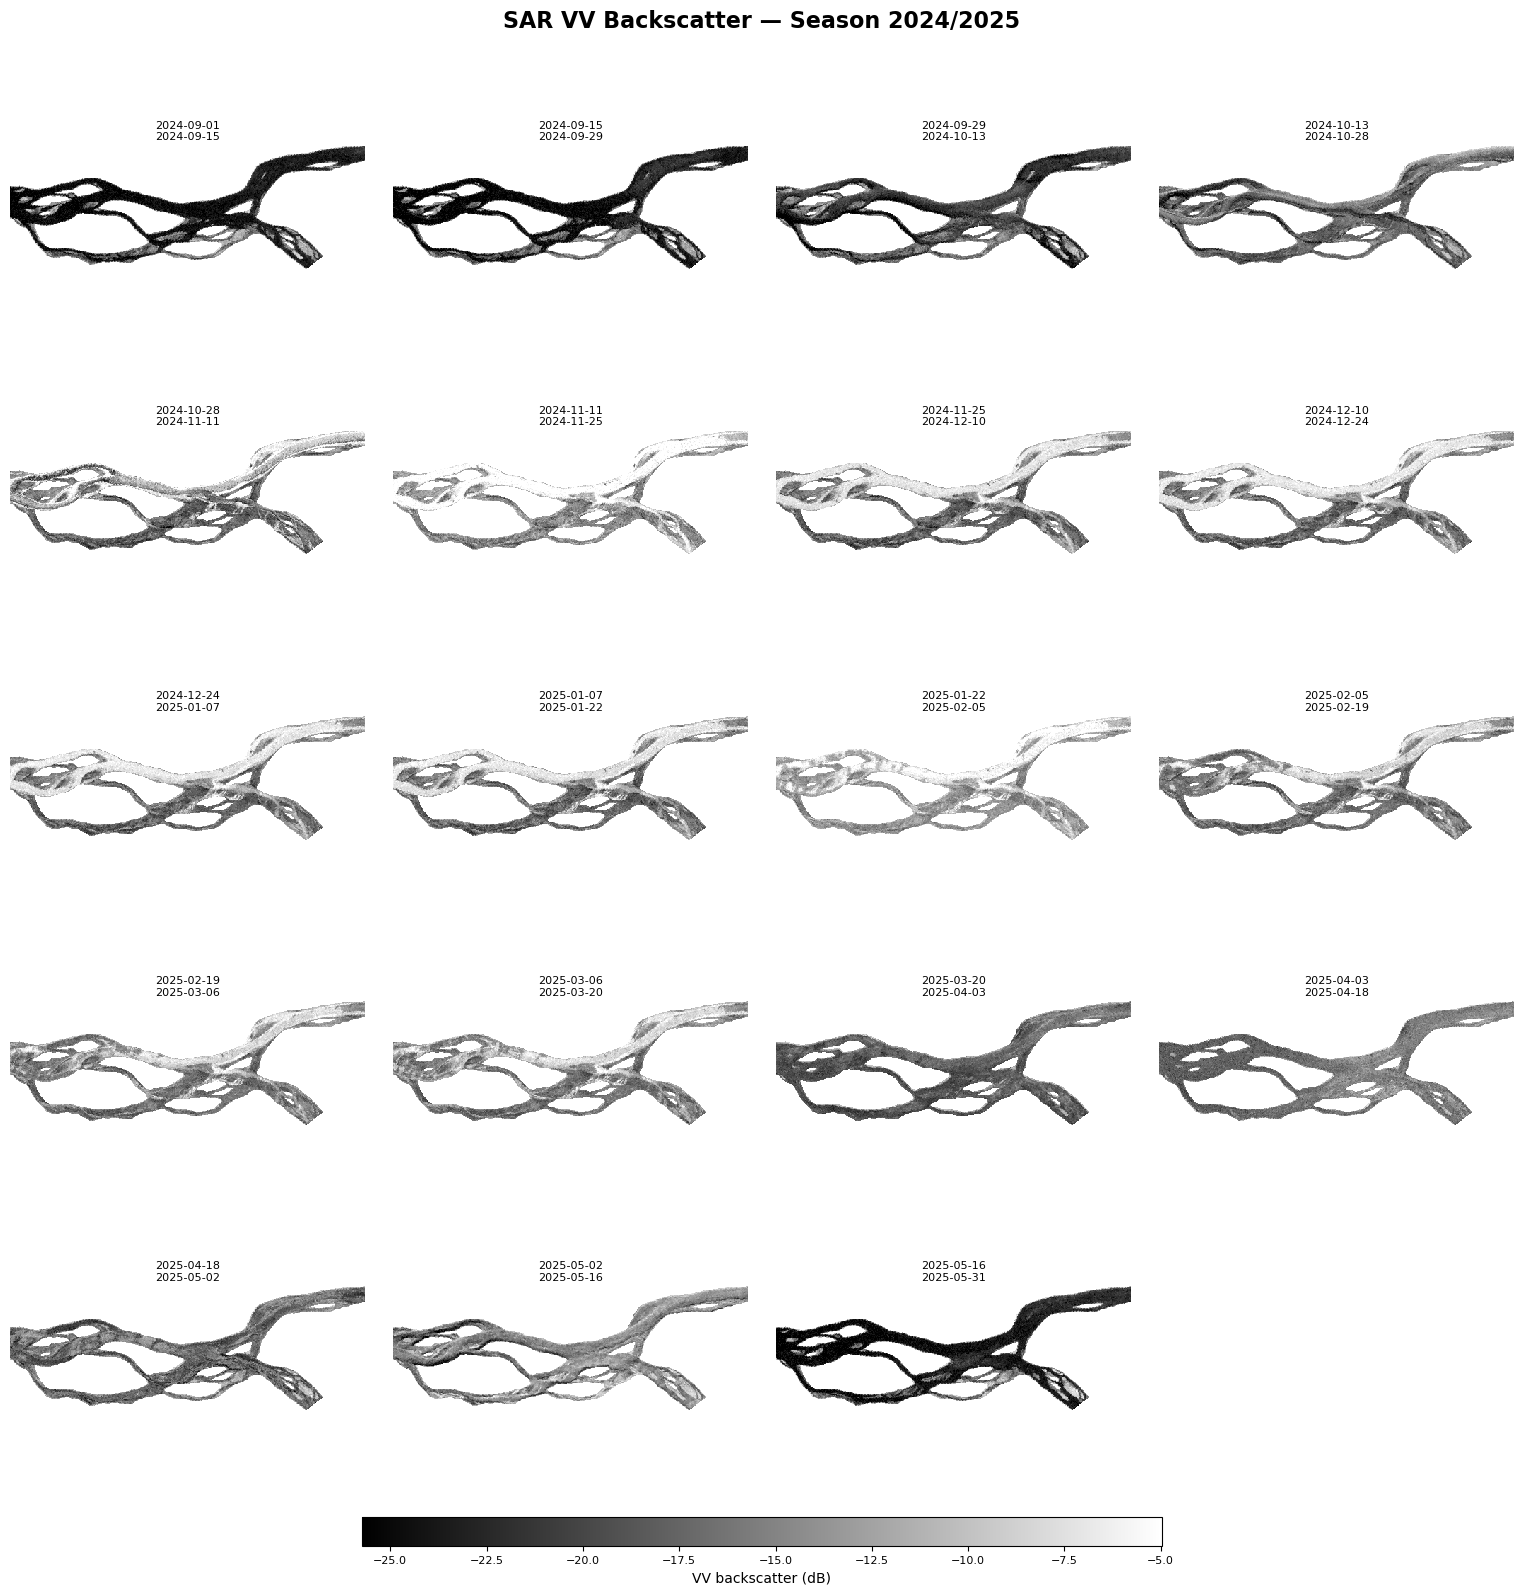

In [29]:
def _valid_vv_db(image: np.ndarray) -> np.ndarray:
    """Return finite VV dB values where Sentinel Hub dataMask is valid."""
    vv = image[:, :, 0]
    data_mask = image[:, :, 1] > 0
    return vv[data_mask & np.isfinite(vv)]


def plot_sar_imagery(sar_data: list, slots: list, title: str) -> None:
    """Plot SAR VV imagery with a clean shared horizontal colorbar."""
    all_valid = [_valid_vv_db(img) for img in sar_data]
    all_valid = [arr for arr in all_valid if arr.size > 0]

    if not all_valid:
        print(f"No valid data available for {title}")
        return

    combined = np.concatenate(all_valid)
    vmin, vmax = np.percentile(combined, [2, 98])

    ncols = 4
    nrows = int(np.ceil(len(slots) / ncols))

    fig, axs = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(16, nrows * 3.2),
        squeeze=False,
    )
    fig.suptitle(title, fontsize=16, fontweight="bold", y=0.995)

    im = None

    for idx, image in enumerate(sar_data):
        ax = axs[idx // ncols][idx % ncols]

        vv = image[:, :, 0].astype(float)
        valid = (image[:, :, 1] > 0) & np.isfinite(vv)
        vv[~valid] = np.nan

        im = ax.imshow(
            vv,
            cmap="gray",
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
        )

        ax.set_title(
            f"{slots[idx][0]}\n{slots[idx][1]}",
            fontsize=8,
            pad=4,
        )
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(False)

        if not np.any(valid):
            ax.text(
                0.5,
                0.5,
                "No data",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=8,
            )

    # Hide any unused panels.
    for idx in range(len(sar_data), nrows * ncols):
        axs[idx // ncols][idx % ncols].set_visible(False)

    # Reserve space below the subplot grid for a single shared colorbar.
    fig.subplots_adjust(
        left=0.03,
        right=0.97,
        top=0.94,
        bottom=0.09,
        wspace=0.08,
        hspace=0.30,
    )

    if im is not None:
        cbar_ax = fig.add_axes([0.25, 0.035, 0.50, 0.018])
        cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
        cbar.set_label("VV backscatter (dB)", fontsize=10)
        cbar.ax.tick_params(labelsize=8)

    plt.show()


for year in START_YEARS:
    plot_sar_imagery(
        season_sar_data[year],
        season_slots[year],
        title=f"SAR VV Backscatter — Season {year}/{year + 1}",
    )

## Representative Seasonal SAR Figure

For a cleaner portfolio-ready figure, the code below selects three representative observations from the first study season:

- **September** — open-water conditions
- **January** — winter/frozen conditions
- **late April / early May** — spring breakup/open-water return

All three panels use the same VV backscatter scale so brightness differences are directly comparable.

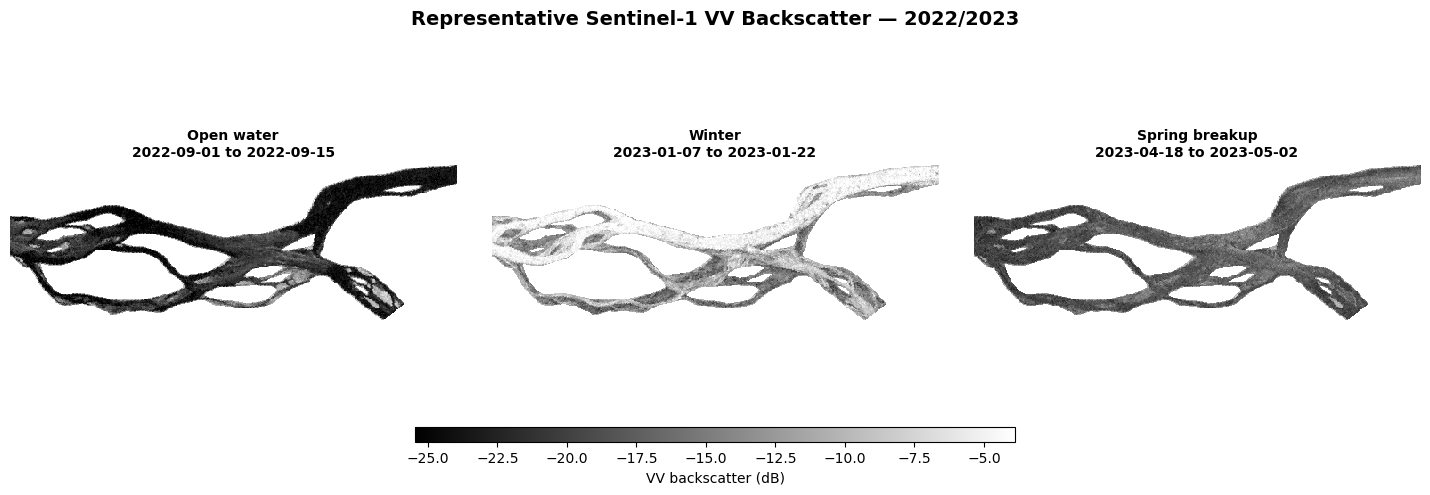

In [30]:
def _find_slot_index_for_month(slots: list, month: int, prefer_last: bool = False):
    """Return a slot index whose midpoint falls in the requested month."""
    candidates = []

    for i, (start, end) in enumerate(slots):
        start_d = datetime.date.fromisoformat(start)
        end_d = datetime.date.fromisoformat(end)
        midpoint = start_d + (end_d - start_d) / 2

        if midpoint.month == month:
            candidates.append(i)

    if not candidates:
        return None

    return candidates[-1] if prefer_last else candidates[0]


def plot_representative_sar(
    sar_data: list,
    slots: list,
    season_label: str,
) -> None:
    """Plot representative open-water, winter, and breakup SAR observations."""
    sep_idx = _find_slot_index_for_month(slots, 9)
    jan_idx = _find_slot_index_for_month(slots, 1)
    apr_idx = _find_slot_index_for_month(slots, 4, prefer_last=True)

    indices = [sep_idx, jan_idx, apr_idx]
    labels = ["Open water", "Winter", "Spring breakup"]

    if any(idx is None for idx in indices):
        print("Could not identify all representative months for this season.")
        return

    valid_arrays = [_valid_vv_db(sar_data[idx]) for idx in indices]
    valid_arrays = [arr for arr in valid_arrays if arr.size > 0]

    if len(valid_arrays) != 3:
        print("One or more representative periods contain no valid SAR data.")
        return

    combined = np.concatenate(valid_arrays)
    vmin, vmax = np.percentile(combined, [2, 98])

    fig, axs = plt.subplots(1, 3, figsize=(15, 4.8))

    im = None
    for ax, idx, label in zip(axs, indices, labels):
        image = sar_data[idx]
        vv = image[:, :, 0].astype(float)
        valid = (image[:, :, 1] > 0) & np.isfinite(vv)
        vv[~valid] = np.nan

        im = ax.imshow(
            vv,
            cmap="gray",
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
        )
        ax.set_title(
            f"{label}\n{slots[idx][0]} to {slots[idx][1]}",
            fontsize=10,
            fontweight="bold",
        )
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(False)

    fig.suptitle(
        f"Representative Sentinel-1 VV Backscatter — {season_label}",
        fontsize=14,
        fontweight="bold",
        y=0.98,
    )

    fig.subplots_adjust(left=0.03, right=0.97, top=0.82, bottom=0.17, wspace=0.08)

    cbar_ax = fig.add_axes([0.30, 0.08, 0.40, 0.03])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
    cbar.set_label("VV backscatter (dB)")

    plt.show()


REPRESENTATIVE_YEAR = START_YEARS[0]

plot_representative_sar(
    season_sar_data[REPRESENTATIVE_YEAR],
    season_slots[REPRESENTATIVE_YEAR],
    season_label=f"{REPRESENTATIVE_YEAR}/{REPRESENTATIVE_YEAR + 1}",
)

## Examine the Backscatter Distributions

Sentinel-1 measures radar backscatter rather than ice directly. Smooth open water often produces relatively weak VV returns because much of the radar energy is reflected away from the sensor, while rougher or structurally complex frozen surfaces can produce stronger returns.

The histograms below therefore show **VV backscatter in actual dB units**, not normalized values.

Important interpretation points:

- the complete observed dB distribution is retained; values above an arbitrary cutoff are no longer discarded
- the red line shows the current working threshold (`ICE_THRESHOLD_DB`)
- a clean ice/water separation is not guaranteed; wind-roughened water, snow/ice properties, and acquisition geometry can cause overlap
- because the AOI contains only river water, the threshold should be calibrated from open-water and winter observations inside the river rather than from surrounding land

This revision uses a **−14 dB** working threshold. It was selected deliberately as a simple, visually interpretable cutoff after comparing known September open-water and January winter backscatter distributions within the river-only AOI. It is not presented as an optimized or universally valid ice threshold.

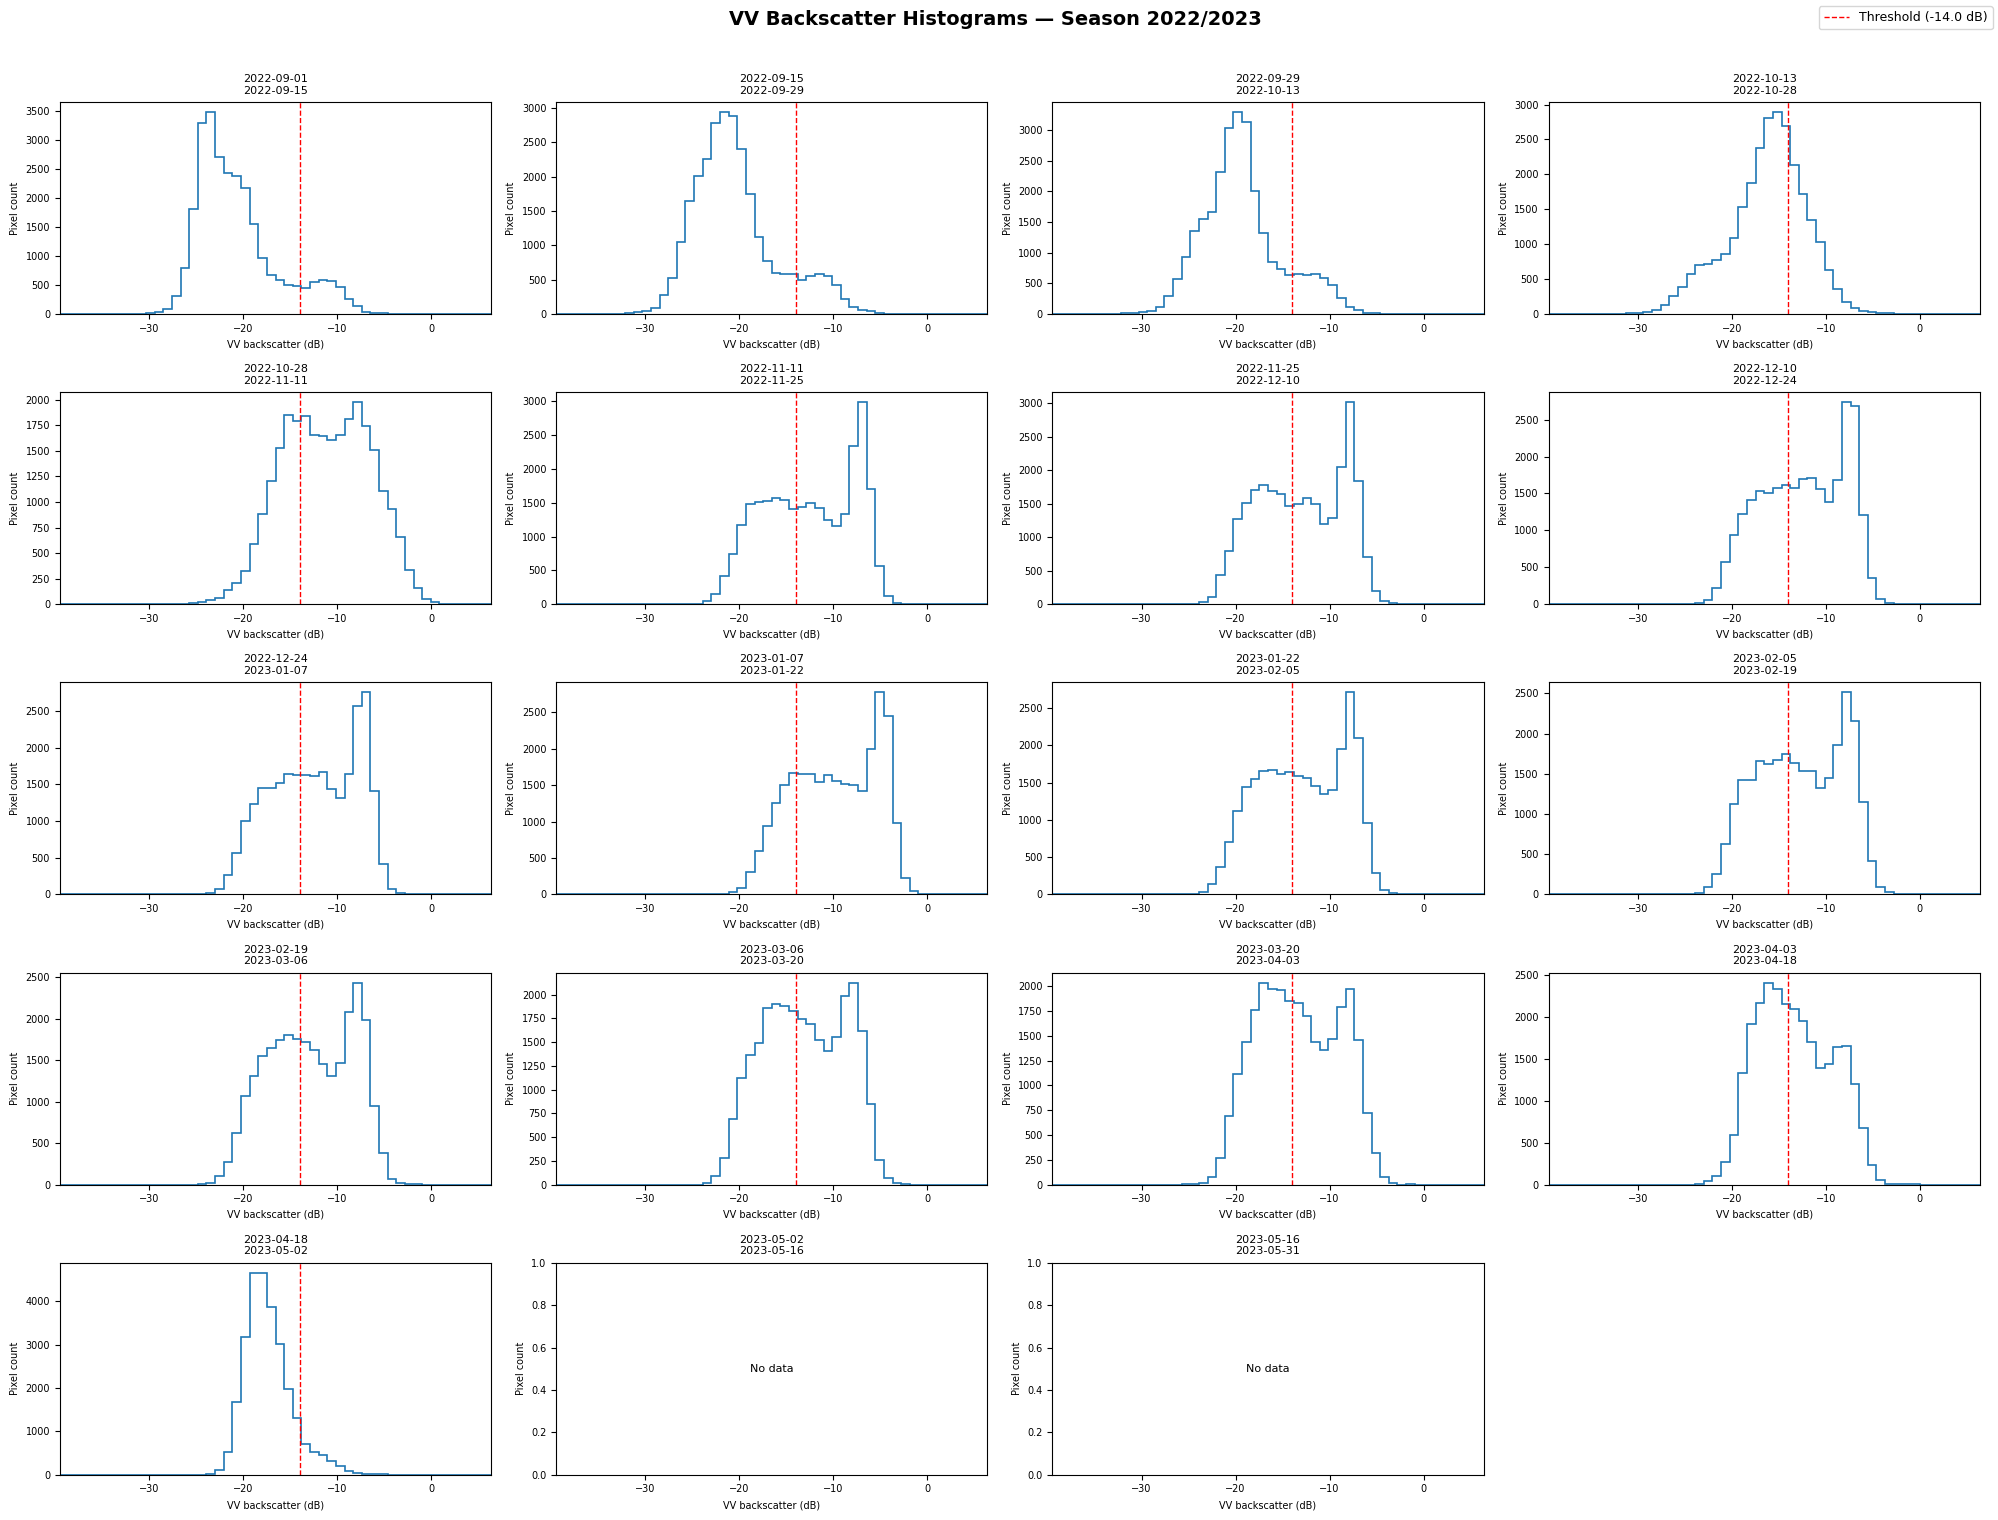

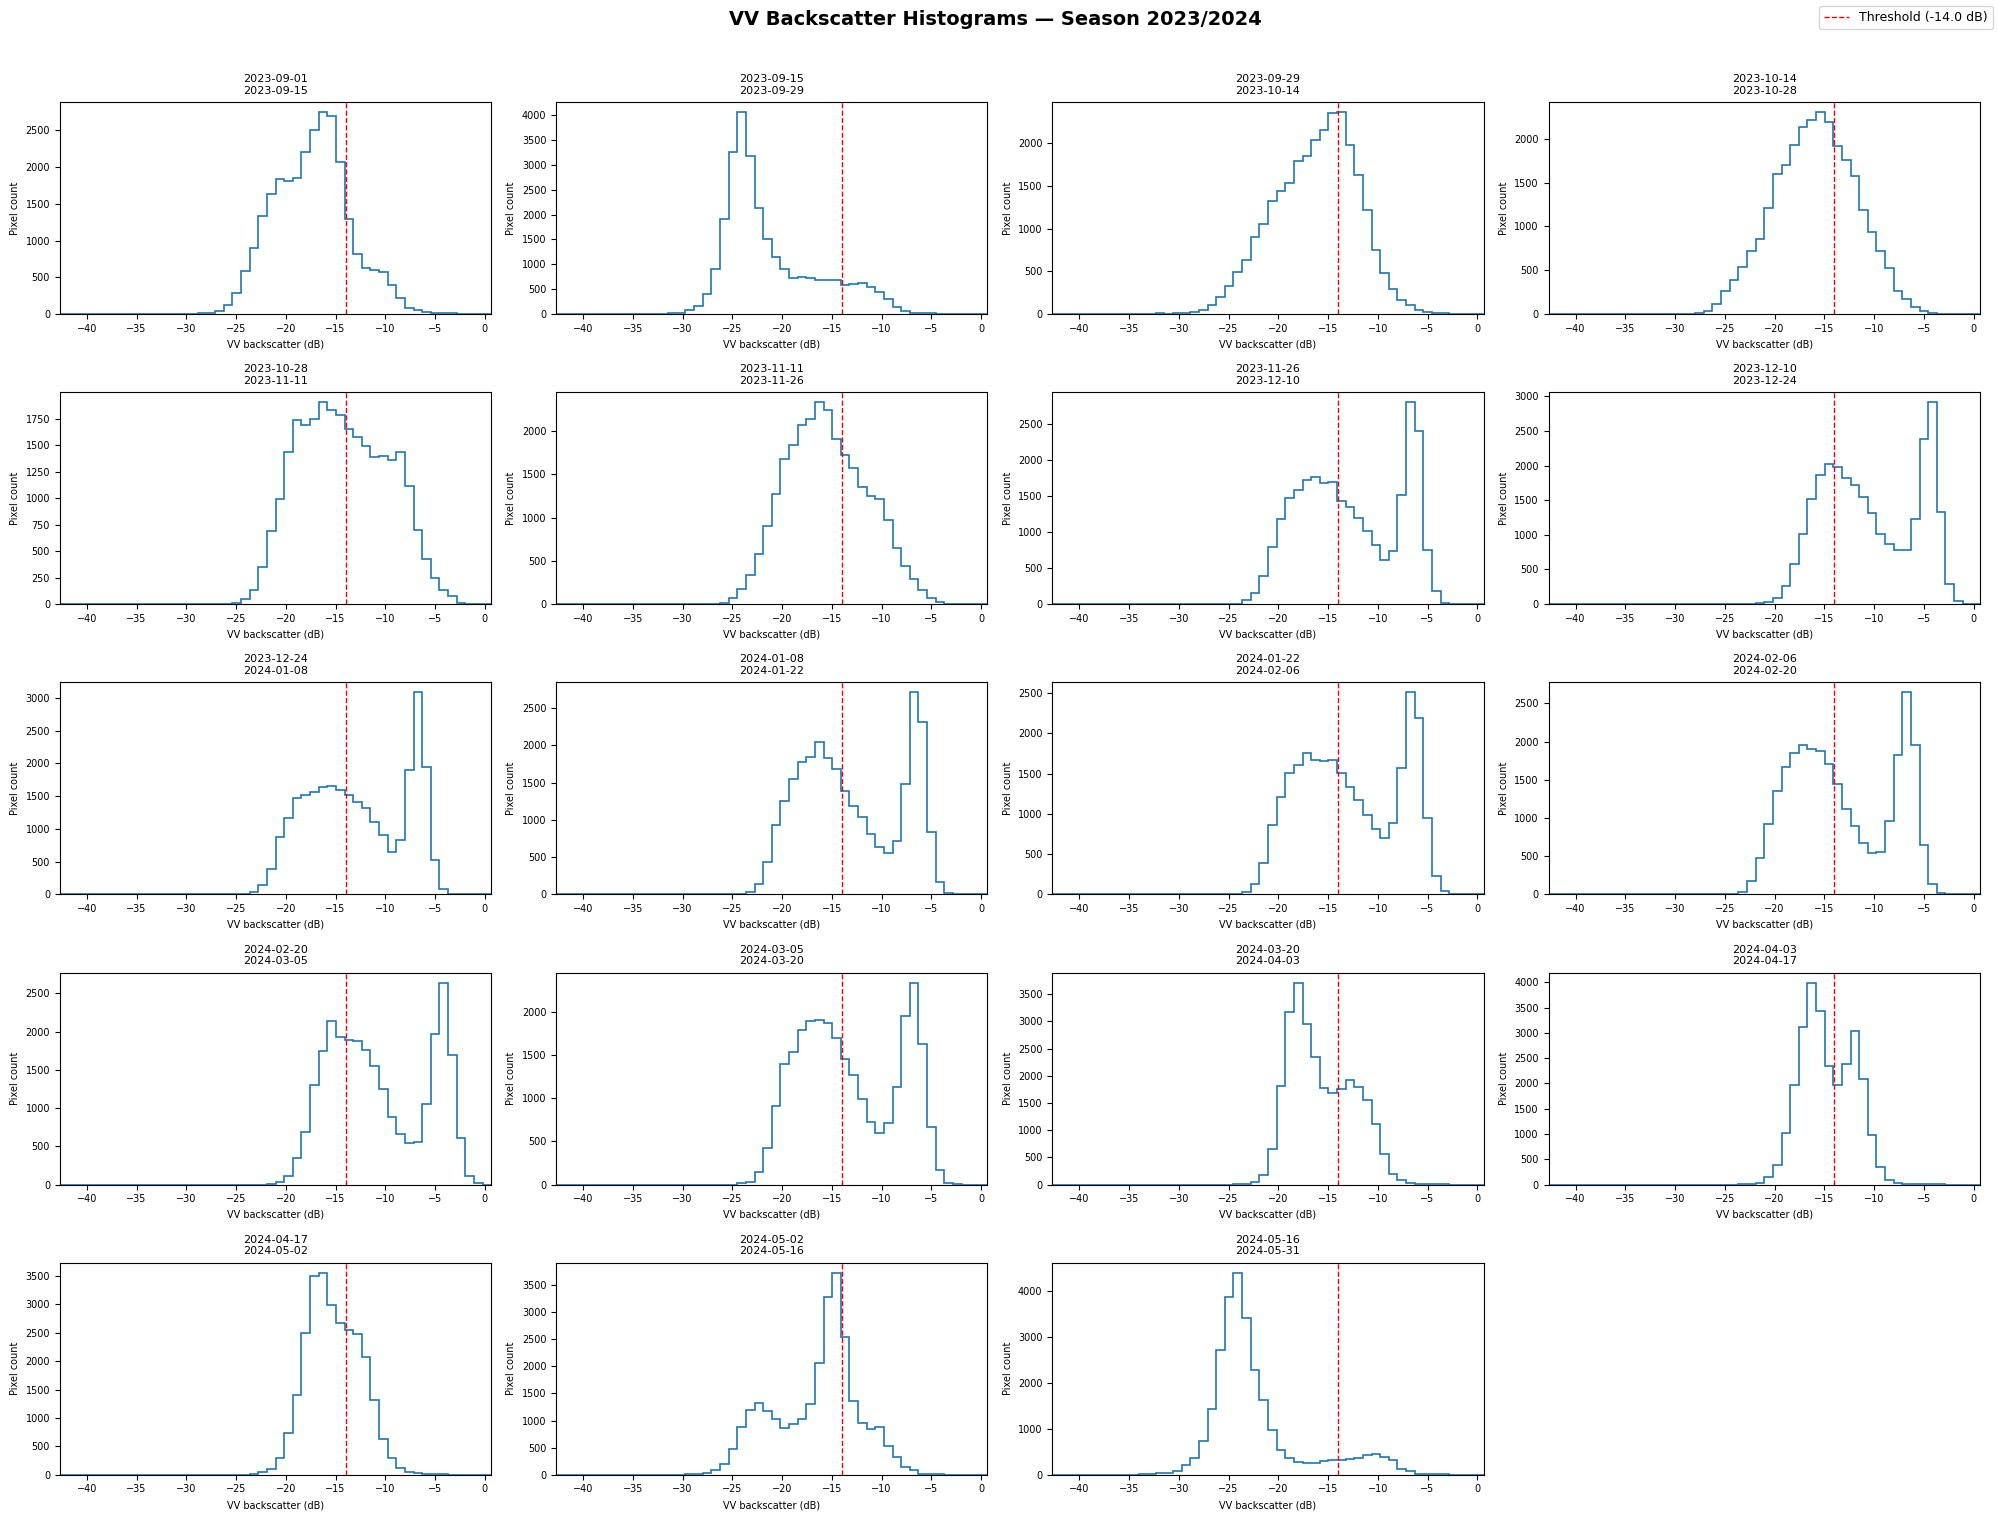

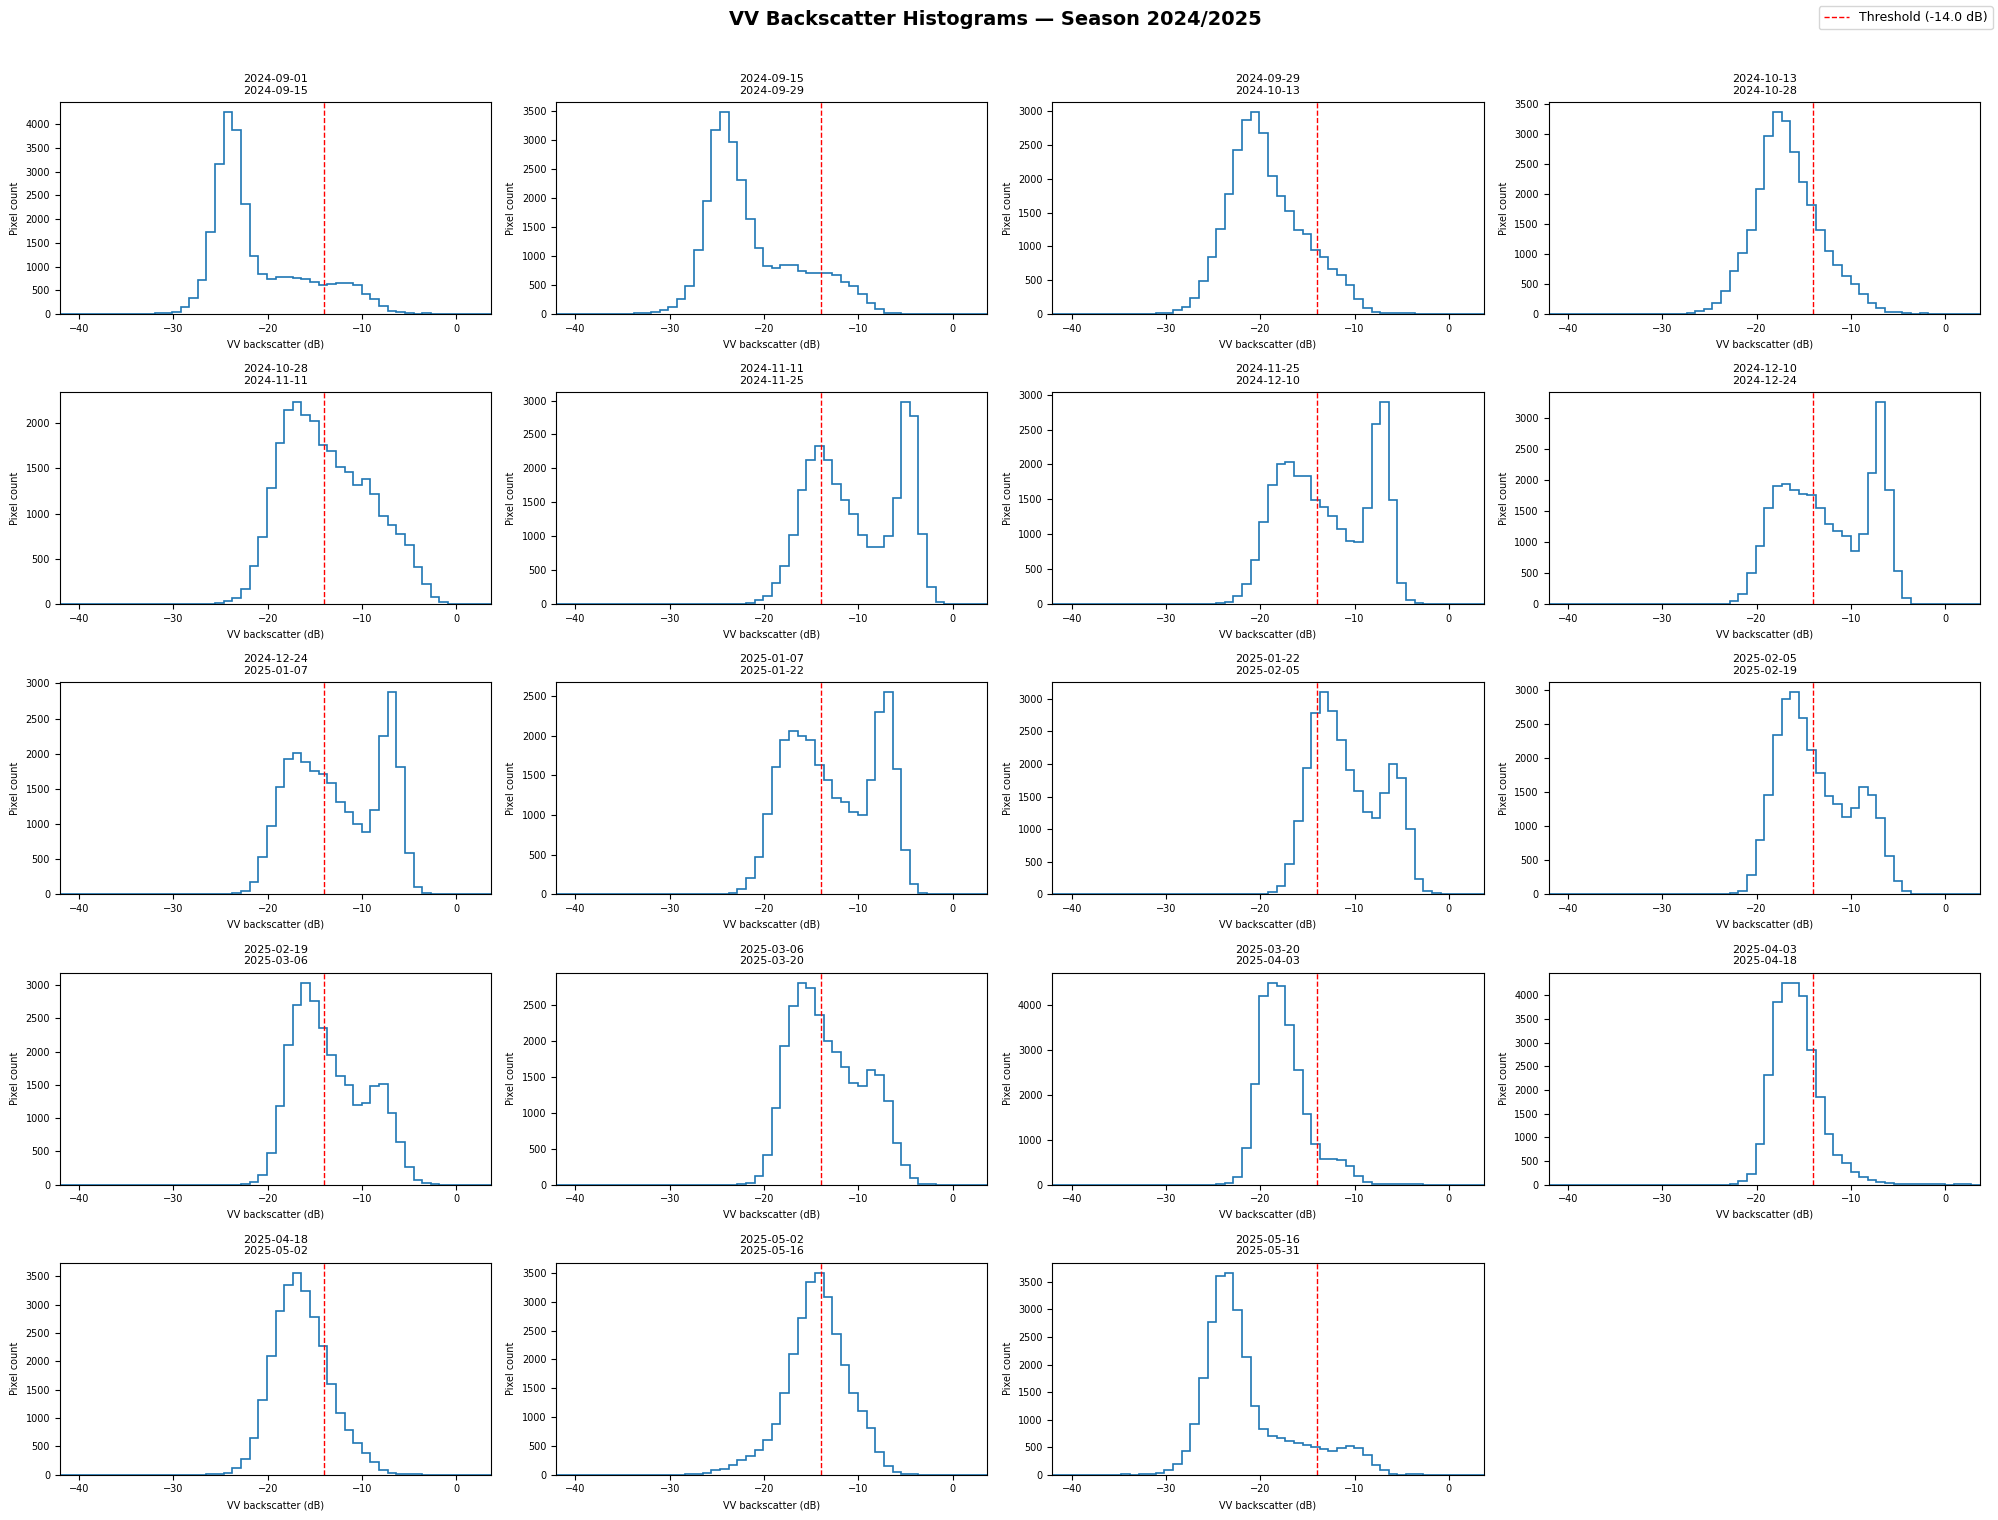

In [31]:
def plot_vv_histograms(sar_data: list, slots: list, title: str) -> None:
    """Plot comparable VV dB histograms for all time slots in one season."""
    valid_arrays = [_valid_vv_db(img) for img in sar_data]
    nonempty = [arr for arr in valid_arrays if arr.size > 0]

    if not nonempty:
        print(f"No valid data available for {title}")
        return

    # One shared set of bin edges spans the full observed range.
    combined = np.concatenate(nonempty)
    global_min = float(np.min(combined))
    global_max = float(np.max(combined))
    bin_edges = np.linspace(global_min, global_max, 51)

    ncols = 4
    nrows = int(np.ceil(len(slots) / ncols))
    fig, axs = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(ncols * 5, nrows * 3),
        squeeze=False,
    )
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)

    for idx, valid_pixels in enumerate(valid_arrays):
        ax = axs[idx // ncols][idx % ncols]

        if valid_pixels.size > 0:
            ax.hist(valid_pixels, bins=bin_edges, histtype="step", linewidth=1.2)
            ax.axvline(
                ICE_THRESHOLD_DB,
                color="red",
                linestyle="--",
                linewidth=1,
                label=f"Threshold ({ICE_THRESHOLD_DB:.1f} dB)",
            )
        else:
            ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                    ha="center", va="center", fontsize=8)

        ax.set_xlim(global_min, global_max)
        ax.set_xlabel("VV backscatter (dB)", fontsize=7)
        ax.set_ylabel("Pixel count", fontsize=7)
        ax.set_title(f"{slots[idx][0]}\n{slots[idx][1]}", fontsize=8)
        ax.tick_params(labelsize=7)

    for idx in range(len(sar_data), nrows * ncols):
        axs[idx // ncols][idx % ncols].set_visible(False)

    handles, labels = axs[0][0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.show()


for year in START_YEARS:
    plot_vv_histograms(
        season_sar_data[year],
        season_slots[year],
        title=f"VV Backscatter Histograms — Season {year}/{year + 1}",
    )

## Open-Water vs Winter Backscatter Comparison

This diagnostic compares known **open-water** observations from September with known **winter** observations from January.

The purpose is interpretive rather than algorithmic: it shows how the two empirical backscatter distributions differ and where the chosen **−14 dB** working threshold falls relative to them.

The threshold is intentionally kept simple for this project. It should be interpreted as a heuristic cutoff for probable ice rather than an optimized or universally transferable classification boundary.

You can change `CALIBRATION_YEAR`, `OPEN_WATER_MONTHS`, or `WINTER_MONTHS` if a selected month has no valid acquisition.

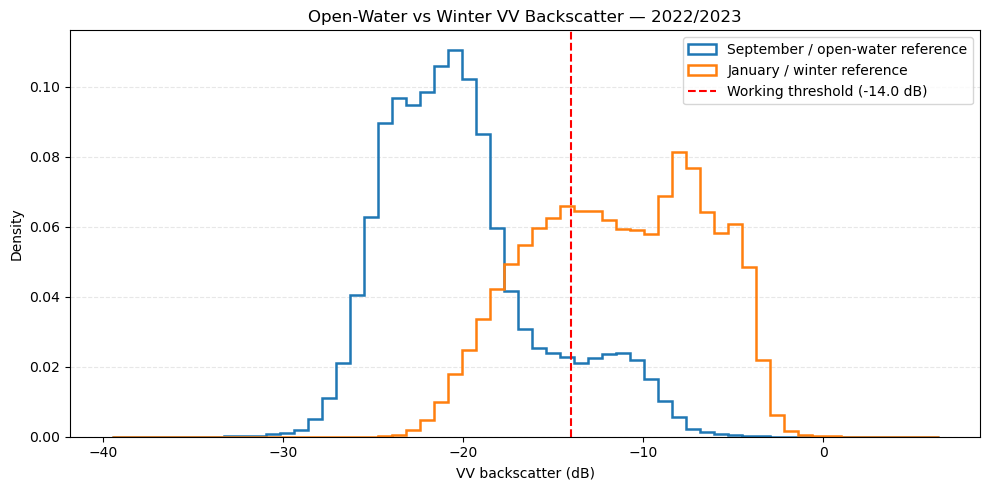

Open-water reference: n=82,068, Q1=-23.25 dB, median=-20.75 dB, Q3=-18.11 dB
Winter reference: n=54,712, Q1=-15.11 dB, median=-11.18 dB, Q3=-7.45 dB

Current working threshold: -14.00 dB


In [32]:
CALIBRATION_YEAR = START_YEARS[0]
OPEN_WATER_MONTHS = {9}
WINTER_MONTHS = {1}


def collect_month_pixels(sar_data: list, slots: list, months: set[int]) -> np.ndarray:
    """Pool valid VV dB pixels from slots whose start date falls in selected months."""
    arrays = []
    for image, slot in zip(sar_data, slots):
        start_month = datetime.date.fromisoformat(slot[0]).month
        if start_month in months:
            values = _valid_vv_db(image)
            if values.size > 0:
                arrays.append(values)

    return np.concatenate(arrays) if arrays else np.array([])


open_pixels = collect_month_pixels(
    season_sar_data[CALIBRATION_YEAR],
    season_slots[CALIBRATION_YEAR],
    OPEN_WATER_MONTHS,
)
winter_pixels = collect_month_pixels(
    season_sar_data[CALIBRATION_YEAR],
    season_slots[CALIBRATION_YEAR],
    WINTER_MONTHS,
)

if open_pixels.size == 0 or winter_pixels.size == 0:
    print(
        "Calibration comparison could not be created because one of the selected "
        "month groups has no valid data. Try a different season or adjacent months."
    )
else:
    combined = np.concatenate([open_pixels, winter_pixels])
    bins = np.linspace(float(np.min(combined)), float(np.max(combined)), 60)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(
        open_pixels,
        bins=bins,
        density=True,
        histtype="step",
        linewidth=1.8,
        label="September / open-water reference",
    )
    ax.hist(
        winter_pixels,
        bins=bins,
        density=True,
        histtype="step",
        linewidth=1.8,
        label="January / winter reference",
    )
    ax.axvline(
        ICE_THRESHOLD_DB,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"Working threshold ({ICE_THRESHOLD_DB:.1f} dB)",
    )
    ax.set_title(f"Open-Water vs Winter VV Backscatter — {CALIBRATION_YEAR}/{CALIBRATION_YEAR + 1}")
    ax.set_xlabel("VV backscatter (dB)")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

    for label, values in [
        ("Open-water reference", open_pixels),
        ("Winter reference", winter_pixels),
    ]:
        q25, median, q75 = np.percentile(values, [25, 50, 75])
        print(
            f"{label}: n={values.size:,}, "
            f"Q1={q25:.2f} dB, median={median:.2f} dB, Q3={q75:.2f} dB"
        )

    print(f"\nCurrent working threshold: {ICE_THRESHOLD_DB:.2f} dB")

## Download Ice Mask Data

Download the classified ice/water masks using the working dB threshold. If the calibration comparison above suggests that `ICE_THRESHOLD_DB` should change, update it in the Configuration cell **before** running this section so the mask request is regenerated consistently.

In [33]:
# Download ice/water classification masks for all seasons
# Results are stored as: season_mask_data[start_year] = list of numpy arrays
season_mask_data: dict[int, list] = {}

for year, slots in season_slots.items():
    print(f"Downloading ice mask data for season {year}/{year + 1} ({len(slots)} slots)...")
    season_mask_data[year] = download_season(slots, get_ice_mask_request)
    valid = sum(1 for img in season_mask_data[year] if np.any(img > 0))
    print(f"  ✓ Done — {valid}/{len(slots)} slots contain valid data\n")

  ✓ Done — 17/19 slots contain valid data

  ✓ Done — 19/19 slots contain valid data

  ✓ Done — 19/19 slots contain valid data



## Visualise Ice / Water Classification Maps

Each panel shows probable ice (cyan) and open-water candidates (blue) inside the river-only AOI. Black indicates no data. Because the classification uses a single VV threshold, the map should be interpreted as a simplified radar-backscatter classification rather than ground-truthed ice extent.

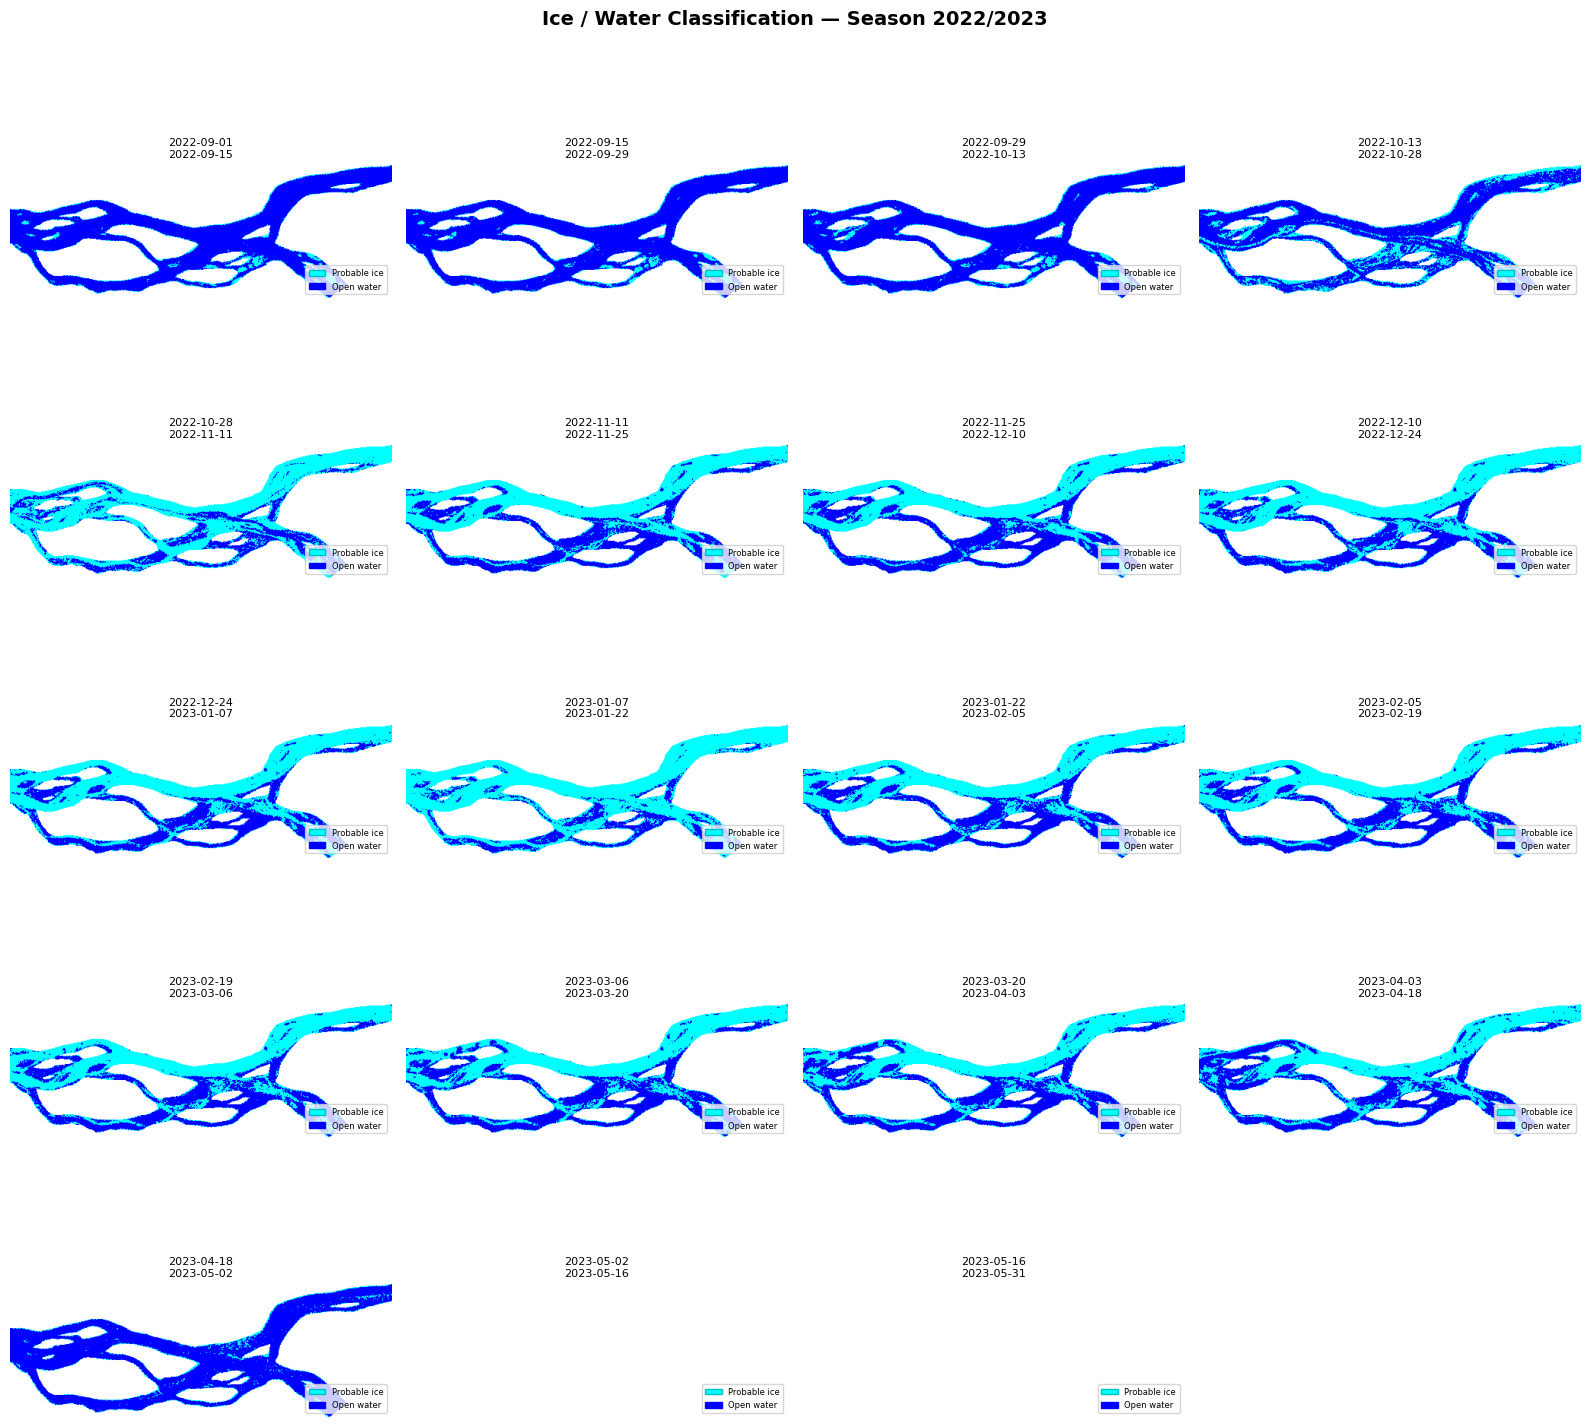

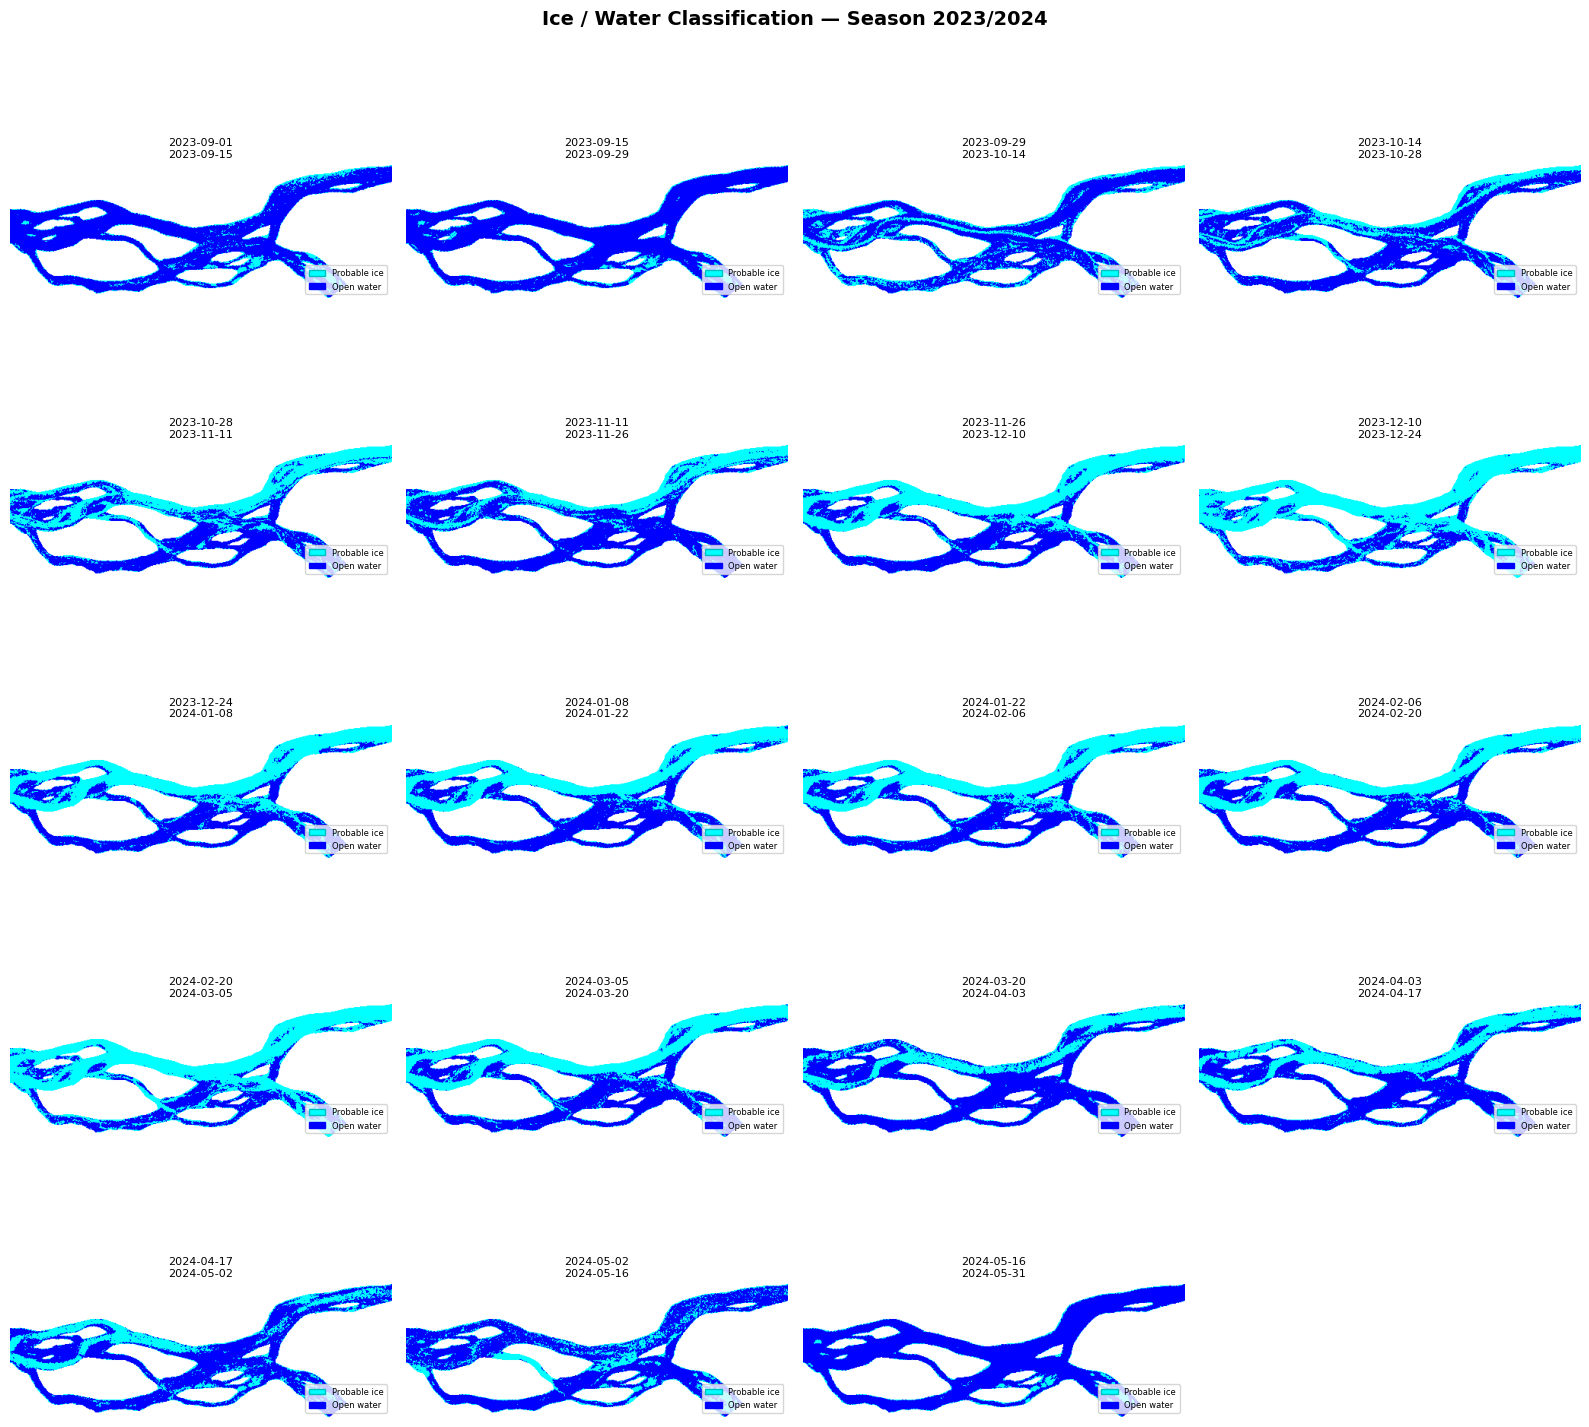

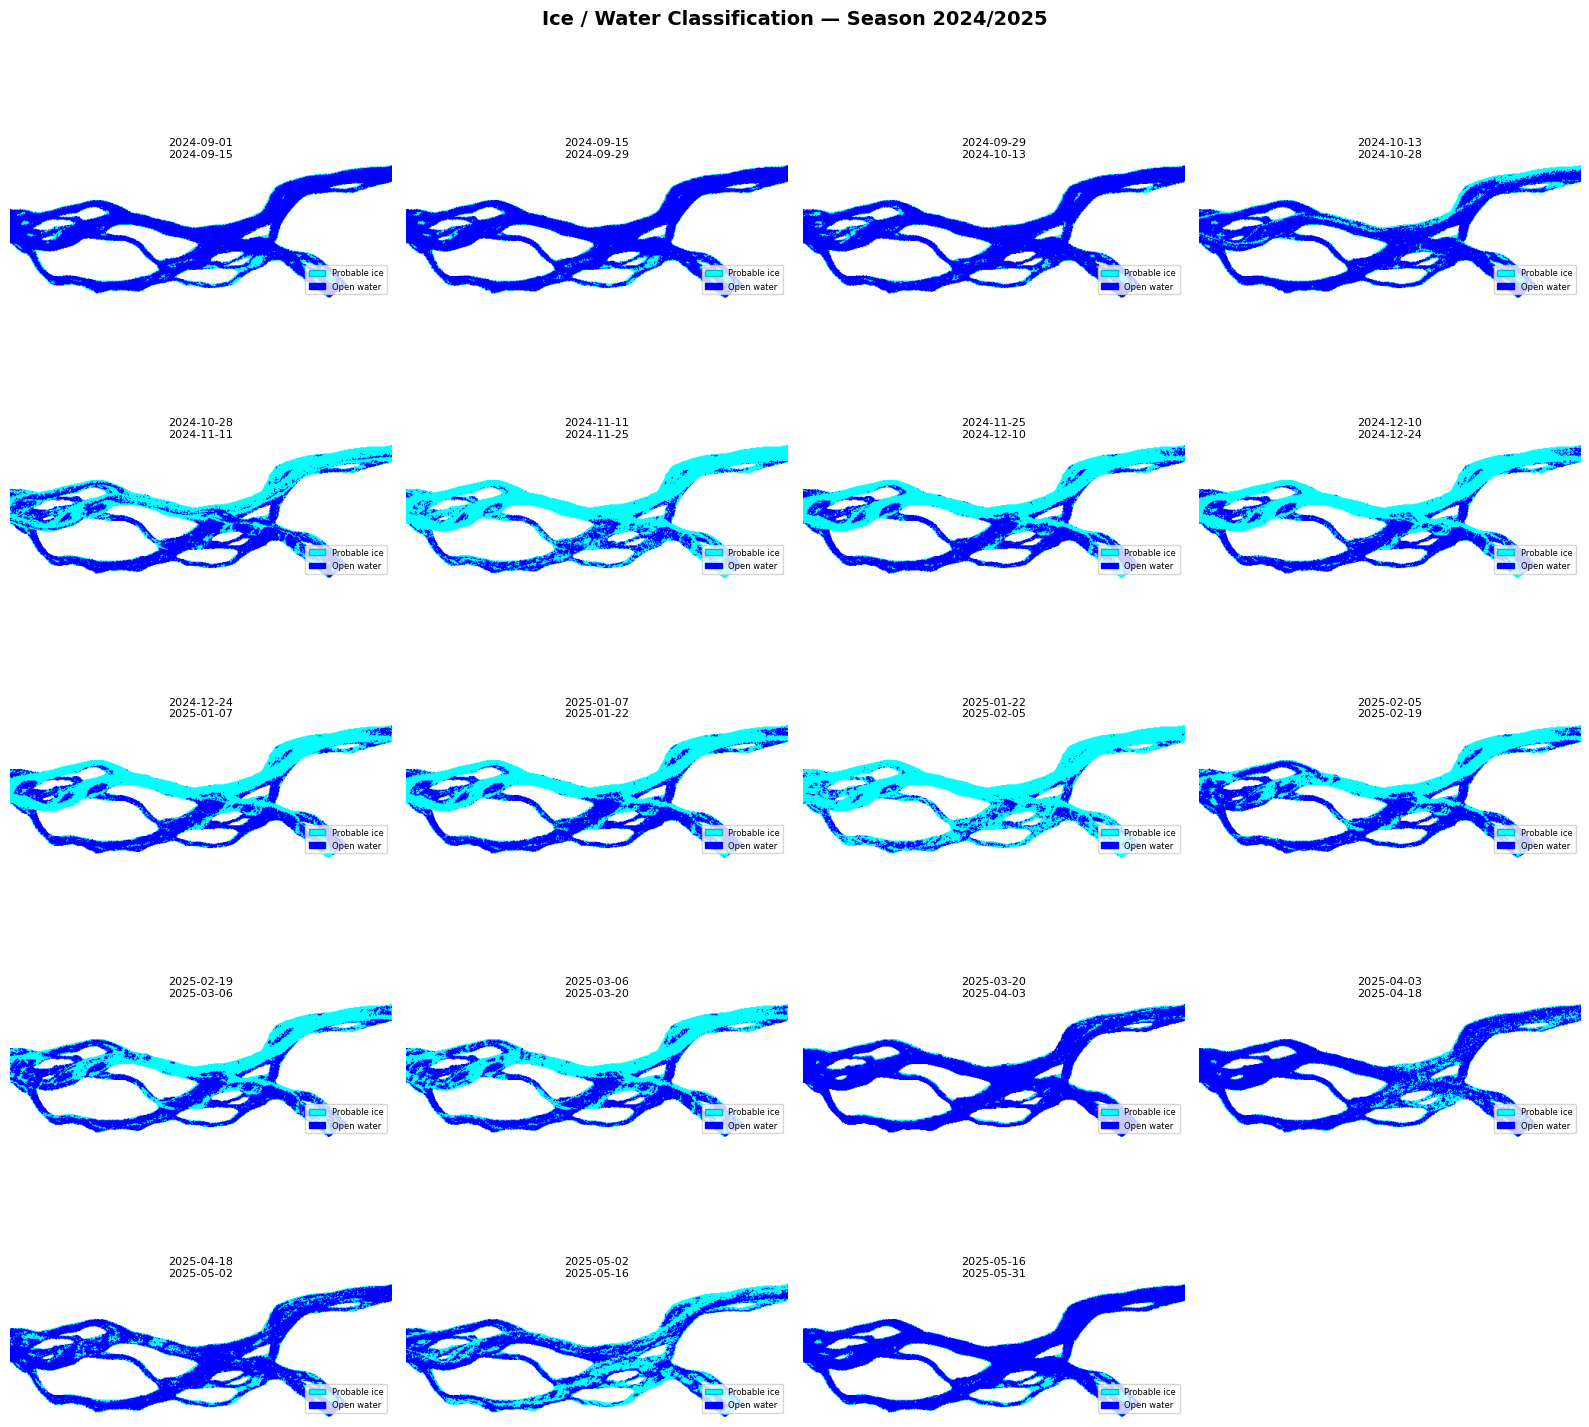

In [34]:
LEGEND_ELEMENTS = [
    Patch(facecolor="cyan", edgecolor="c", label="Probable ice"),
    Patch(facecolor="blue", edgecolor="b", label="Open water"),
]


def plot_ice_masks(mask_data: list, slots: list, title: str) -> None:
    """Plot classified ice/water maps for all time slots in one season.

    Args:
        mask_data: List of UINT8 numpy arrays (one per slot, 5 bands).
        slots: Corresponding list of (start, end) date string tuples.
        title: Figure suptitle.
    """
    ncols = 4
    nrows = int(np.ceil(len(slots) / ncols))

    fig, axs = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(ncols * 4, nrows * 3),
        subplot_kw={"xticks": [], "yticks": [], "frame_on": False},
        squeeze=False,
    )

    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)

    for idx, image in enumerate(mask_data):
        ax = axs[idx // ncols][idx % ncols]

        # Band 3 = valid-data mask
        # Band 4 = probable-ice classification
        valid = image[:, :, 3] > 0
        ice = image[:, :, 4] > 0
        water = valid & ~ice

        # Start with a white background:
        # outside AOI / no data = white
        display = np.ones(
            (image.shape[0], image.shape[1], 3),
            dtype=float,
        )

        # Open water = blue
        display[water] = [0, 0, 1]

        # Probable ice = cyan
        display[ice & valid] = [0, 1, 1]

        ax.imshow(display)

        ax.set_title(
            f"{slots[idx][0]}\n{slots[idx][1]}",
            fontsize=8,
        )

        ax.legend(
            handles=LEGEND_ELEMENTS,
            loc="lower right",
            fontsize=6,
        )

    # Hide unused subplot panels
    for idx in range(len(mask_data), nrows * ncols):
        axs[idx // ncols][idx % ncols].set_visible(False)

    plt.tight_layout()
    plt.show()


for year in START_YEARS:
    plot_ice_masks(
        season_mask_data[year],
        season_slots[year],
        title=f"Ice / Water Classification — Season {year}/{year + 1}",
    )

## Time Series of Ice-Covered Area

Ice-covered area (km²) is calculated by counting valid river pixels classified as probable ice and multiplying by the 40 m × 40 m pixel footprint.

As in the original version of the notebook, all three study seasons are plotted **on top of one another along the same September-to-May seasonal axis**. This makes the overall freeze-up and breakup pattern easier to compare across years.

Time slots with no valid SAR observation are plotted as missing values rather than 0 km².

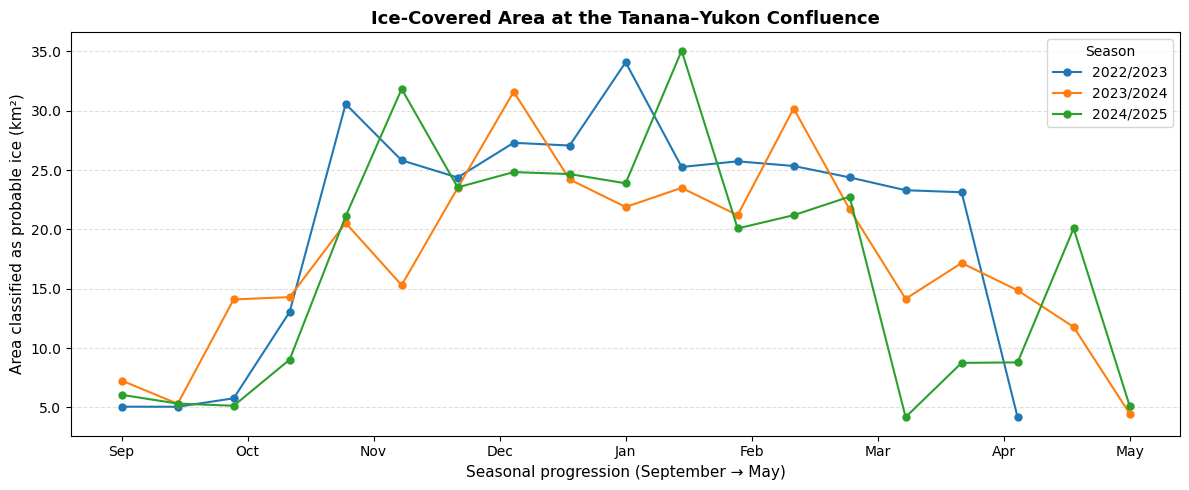

In [35]:
def compute_ice_area(
    mask_data: list,
    pixel_resolution_m: int = RESOLUTION,
) -> list[float]:
    """Calculate probable ice-covered area in km² for each time slot."""
    pixel_area_km2 = (pixel_resolution_m ** 2) / 1_000_000

    ice_area_km2 = []

    for image in mask_data:
        valid = image[:, :, 3] > 0
        ice = (image[:, :, 4] > 0) & valid

        if not np.any(valid):
            ice_area_km2.append(np.nan)
            continue

        n_ice = int(np.count_nonzero(ice))
        ice_area_km2.append(n_ice * pixel_area_km2)

    return ice_area_km2


season_ice_area: dict[int, list[float]] = {
    year: compute_ice_area(season_mask_data[year])
    for year in START_YEARS
}

# ── Combined multi-season time series plot ────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

for year in START_YEARS:
    ice_area = season_ice_area[year]

    ax.plot(
        range(len(ice_area)),
        ice_area,
        marker="o",
        markersize=5,
        linewidth=1.5,
        label=f"{year}/{year + 1}",
    )

# Shared seasonal x-axis: position labels at approximate month locations.
n_slots = len(season_slots[START_YEARS[0]])
month_labels = ["Sep", "Oct", "Nov", "Dec", "Jan", "Feb", "Mar", "Apr", "May"]
month_positions = np.linspace(0, n_slots - 1, len(month_labels))

ax.set_xticks(month_positions)
ax.set_xticklabels(month_labels)

ax.set_title(
    "Ice-Covered Area at the Tanana–Yukon Confluence",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Seasonal progression (September → May)", fontsize=11)
ax.set_ylabel("Area classified as probable ice (km²)", fontsize=11)
ax.legend(title="Season", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x:.1f}")
)

plt.tight_layout()
plt.show()

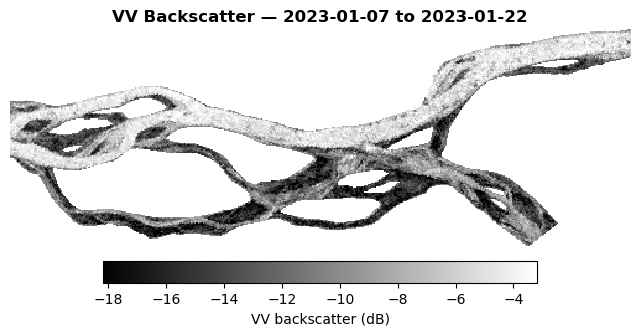

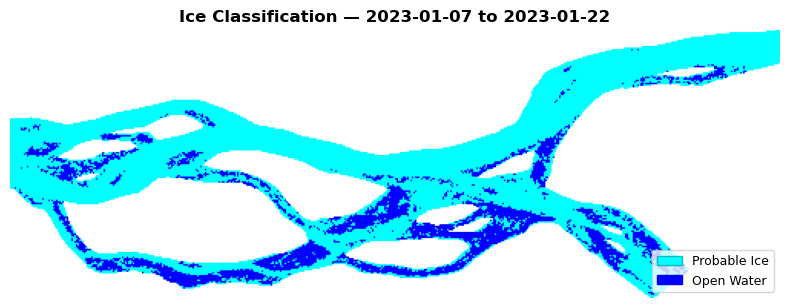

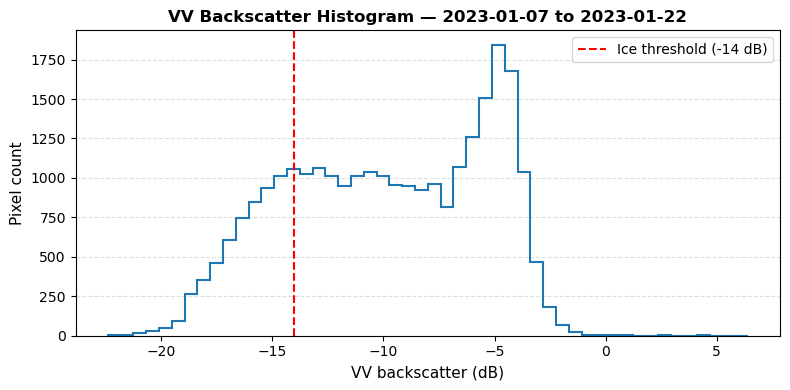

In [37]:
# ── Export figures for project write-up ──────────────────────────────────────

from pathlib import Path

EXPORT_YEAR = 2022
EXPORT_IDX = 9

EXPORT_SLOT = season_slots[EXPORT_YEAR][EXPORT_IDX]
SLOT_LABEL = f"{EXPORT_SLOT[0]} to {EXPORT_SLOT[1]}"

OUTPUT_DIR = Path("../outputs/images")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Use the threshold already defined in the notebook configuration.
EXPORT_THRESHOLD_DB = ICE_THRESHOLD_DB


# ── 1. SAR Backscatter ────────────────────────────────────────────────────────
sar_image = season_sar_data[EXPORT_YEAR][EXPORT_IDX]

vv_db = sar_image[:, :, 0].astype(float)
data_mask = sar_image[:, :, 1] > 0

# Mask no-data pixels.
vv_display = vv_db.copy()
vv_display[~data_mask | ~np.isfinite(vv_display)] = np.nan

# Use percentile-based display scaling, consistent with the revised notebook.
valid_vv = vv_display[np.isfinite(vv_display)]
vmin, vmax = np.percentile(valid_vv, [2, 98])

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(
    vv_display,
    cmap="gray",
    vmin=vmin,
    vmax=vmax,
    interpolation="nearest",
)

ax.set_title(
    f"VV Backscatter — {SLOT_LABEL}",
    fontsize=12,
    fontweight="bold",
)
ax.axis("off")

# Add a compact dB scale.
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.04,
    shrink=0.7,
)
cbar.set_label("VV backscatter (dB)", fontsize=10)

plt.savefig(
    OUTPUT_DIR / "sar_jan_2023.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


# ── 2. Ice Classification ─────────────────────────────────────────────────────
mask_image = season_mask_data[EXPORT_YEAR][EXPORT_IDX]

# Band 3 = valid-data mask
# Band 4 = probable-ice classification
valid = mask_image[:, :, 3] > 0
ice = mask_image[:, :, 4] > 0
water = valid & ~ice

# Start with a white RGB image:
# outside AOI / no data = white
display = np.ones(
    (mask_image.shape[0], mask_image.shape[1], 3),
    dtype=float,
)

# Open water = blue
display[water] = [0, 0, 1]

# Probable ice = cyan
display[ice & valid] = [0, 1, 1]

legend_elements = [
    Patch(
        facecolor="cyan",
        edgecolor="c",
        label="Probable Ice",
    ),
    Patch(
        facecolor="blue",
        edgecolor="b",
        label="Open Water",
    ),
]

fig, ax = plt.subplots(figsize=(8, 5))

ax.imshow(display)

ax.set_title(
    f"Ice Classification — {SLOT_LABEL}",
    fontsize=12,
    fontweight="bold",
)

ax.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=9,
)

ax.axis("off")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "ice_classification_jan_2023.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


# ── 3. VV Backscatter Histogram ───────────────────────────────────────────────
valid_pixels = vv_db[
    data_mask & np.isfinite(vv_db)
]

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    valid_pixels,
    bins=50,
    histtype="step",
    linewidth=1.5,
)

ax.axvline(
    EXPORT_THRESHOLD_DB,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Ice threshold ({EXPORT_THRESHOLD_DB:.0f} dB)",
)

ax.set_title(
    f"VV Backscatter Histogram — {SLOT_LABEL}",
    fontsize=12,
    fontweight="bold",
)

ax.set_xlabel("VV backscatter (dB)", fontsize=11)
ax.set_ylabel("Pixel count", fontsize=11)

ax.legend(fontsize=10)
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4,
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "histogram_jan_2023.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

## Summary

This revised notebook applies a Sentinel-1 SAR threshold-classification workflow to three freeze-thaw seasons at the Tanana–Yukon River confluence.

**Key methodological choices and revisions:**

- VV backscatter is analyzed directly in **decibels (dB)** rather than on a custom normalized 0–1 scale.
- The river-only GeoJSON limits the analysis to water surfaces and avoids the need to compensate for surrounding boreal land cover.
- A simple working threshold of **−14 dB** is used to separate lower-backscatter open-water candidates from higher-backscatter probable ice.
- The −14 dB cutoff was selected heuristically after visual comparison of known September open-water and January winter backscatter distributions; it is **not** presented as an algorithmically optimized or universally transferable threshold.
- Histograms retain the full observed backscatter distribution.
- The time-slot function creates **19 complete intervals** covering September 1 through May 31.
- Sentinel Hub credentials are loaded from environment variables rather than stored in the notebook.
- New mask-cache folders prevent products from earlier threshold versions from being reused accidentally.
- The final seasonal time series overlays all three study years on a common September-to-May axis for direct interannual comparison.

**Interpretive limitations:**

- A single VV threshold is a simplified classifier. Wind-roughened open water, snow and ice properties, incidence angle, and other SAR acquisition conditions can cause overlap between open-water and ice backscatter.
- Sparse Sentinel-1 acquisition may leave some approximately two-week slots without observations.
- Results should therefore be described as **probable ice / open-water classification** rather than ground-truthed ice extent.

Sentinel-1 remains useful for this application because SAR can observe the river through cloud cover and does not depend on daylight, both important advantages at high latitudes.